In [34]:
import pandas as pd 
import numpy as np 
from glob import glob
import os
import geopandas as gpd

import csv
import json

from ast import literal_eval

pd.set_option('display.max_columns', None)


# Important reference info about regions about data for dissertation
- Understanding regions
    - Each entry (event) from NCEI events database is unique by region
    - The "type" of region that it is is either a Zone or County. 
    - But note that one entry (one event) won't be duplicated with entries from both a Zone and County (see counts below being equal after dropping duplicates), it's just that some entries come from zone OR county. 
        - NWS Directive 10-1605 strictly categorizes every single Event Type into one of two buckets -- see page 4/5 from https://www.weather.gov/media/directives/010_pdfs/pd01016005curr.pdf
            - Always a Zone (Z): Heavy Snow, Winter Storm, Blizzard, Lake-Effect Snow, etc. 
                - So while I didn't filter out Counties from our analyses, we're only using events that USE zones, so saying that we follow NWS zones is accurate for the dissertation
            - Always a County (C): Tornado, Flash Flood, Hail, Thunderstorm Wind, Lightning, etc. 
- Understanding flow of prepping model data: 1) isolate datetimes needed for a model run instance 2) run model pred set 3) run /home/csutter/DRIVE-clean/weather_events/notebooks/cam_modelpred_QPE.py to add QPE to data 4) run agg stats, /home/csutter/DRIVE-clean/weather_events/notebooks/stats_events_modelpred.py 5) add the resulting file to read in as csv (in this code below)

In [ ]:
# NCEI data
d_readin = gpd.read_file("/home/csutter/DRIVE-clean/weather_events/data/ncei_events/ncei_ny_events_clean.gpkg")

d_readin.head(4)

# add timedelta duration col back (using duration_sec col)
# note that you have to do this w/ every gdf
d_readin["duration"] = pd.to_timedelta(d_readin["duration_sec"], unit="s")

In [ ]:
# For reference
ss = d_readin[["CZ_TYPE","EVENT_ID"]]
display(ss.head(4))
print(len(ss))
nodup = ss.drop_duplicates()
print(len(nodup))

display(ss.groupby("CZ_TYPE").count())

In [ ]:
ss = d_readin[["CZ_TYPE","CZ_NAME","EVENT_ID"]]
display(ss.head(4))
print(len(ss))
nodup = ss.drop_duplicates()
print(len(nodup))

display(ss.groupby("CZ_TYPE").count())

# Read in / prepare data for case studies

In [2]:
# NCEI data
d_readin = gpd.read_file("/home/csutter/DRIVE-clean/weather_events/data/ncei_events/ncei_ny_events_clean.gpkg")

d_readin.head(4)

# add timedelta duration col back (using duration_sec col)
# note that you have to do this w/ every gdf
d_readin["duration"] = pd.to_timedelta(d_readin["duration_sec"], unit="s")

In [3]:
#### combine buffer datasets
# 1 - the buffer trackers


buffer1 = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/data/nonevents_ofinterest/buffertimes_for_nceievents.csv")

display(buffer1.head(2))

print(len(buffer1))

buffer2 = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/data/nonevents_ofinterest/buffertimes_extra_for_casestudies.csv")

display(buffer2.head(2))

print(len(buffer2))

buffertracker = pd.concat([buffer1, buffer2])

print(len(buffertracker))

# 2 - The aggregate stats from buffer data

stats_buffer1 = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_buffer_rsc.csv")
# ("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_buffer.csv") # note that this has a lot more data in it than the buffer tracker (what we actually needed to run). Why? bc when we do operations model preds, we run it statewide -- so ALL locations / wfos (for all cams) are included in the stats here. We will want to inner join with the tracker, buffertracker to grab just those that we needed. 

print(len(stats_buffer1))

stats_buffer2 = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_bufferExtraCaseStudies_rsc.csv")

print(len(stats_buffer2))

stats_buffer = pd.concat([stats_buffer1,stats_buffer2])
print(len(stats_buffer))

,Unnamed: 0,buffer_for_event_id,buffer_type,buffer_datetime,buffer_loc,buffer_wfo
0,0,996866,before,20220129_1100,SOUTHWEST SUFFOLK,OKX
1,1,996866,before,20220129_1115,SOUTHWEST SUFFOLK,OKX


3768


,Unnamed: 0,buffer_for_event_id,buffer_type,buffer_datetime,buffer_loc,buffer_wfo
0,0,996866,before,20220129_0000,SOUTHWEST SUFFOLK,OKX
1,1,996866,before,20220129_0030,SOUTHWEST SUFFOLK,OKX


189
3957
73567
9106
82673


In [4]:
display(stats_buffer.head(3))

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,model_probs,prob_avg,model_qpe,qpe_avg
0,20220129_1100,20220129_1100,buffer,ALLEGANY,BUF,20220129_1100,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6717', 'Skyline_5651']","{""dry"": 1, ""snow"": 1}","{""dry"": 0.321, ""snow"": 0.46}",0.390649,"{'dry': 0.0, 'snow': 0.0}",0.0000
1,20220129_1100,20220129_1100,buffer,BRONX,OKX,20220129_1100,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_5781', 'Skyline_5798', 'Skyline_5796...","{""snow"": 33, ""snow_severe"": 36}","{""snow"": 0.625, ""snow_severe"": 0.613}",0.618771,"{'snow': 0.939, 'snow_severe': 1.022}",0.9826
2,20220129_1100,20220129_1100,buffer,BROOME,BGM,20220129_1100,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6245', 'Skyline_5681', 'Skyline_5680...","{""dry"": 8, ""poor_viz"": 5, ""snow"": 1, ""wet"": 1}","{""dry"": 0.425, ""poor_viz"": 0.33, ""snow"": 0.465...",0.402897,"{'dry': 0.0, 'poor_viz': 0.0, 'snow': 0.0, 'we...",0.0000


In [5]:

stats_events = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_MRMS_events_rsc.csv")
# ("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_wQPE.csv") #HERE!! stats_wQPE.csv or stats.csv

# Combine w/ their buffers (read in above)

stats_buffer = stats_buffer.drop(columns = ['id_event','id_ep']) # these were just set to the datetimes, meaningless at the moment
stats_buffer = stats_buffer.rename(columns = {"id_type":"type"})

# To connect the buffer data to the events data, use the buffer tracker dataframe we saved out which has the event (id_event), buffer times, location. The code for setting up that df was in /home/csutter/DRIVE-clean/weather_events/notebooks/ncei_dataset_analysis.ipynb (but the data is saved out and we can use it), but it can be merged to stats_buffer via location, which will tie the event id to buffer -- which is what we need here for plotting buffer times with the events themselcves
# issue with the main buffer stats is that we did not save eventid with it (just used the datetime)
# buffertracker is read in above

stats_buffer_connect = stats_buffer.merge(buffertracker, how = "inner", left_on = ["id_loc", "id_wfo", "datetime"], right_on = ["buffer_loc", "buffer_wfo", "buffer_datetime"])

# adjust cols

# rename cols to match stats_events so that concat of dfs is clean
# stats_buffer_use = stats_buffer_connect.rename(columns = {"buffer_for_event_id":"id_event","buffer_wfo":"id_wfo","buffer_loc":"id_loc"})

stats_buffer_connect['id_type'] = stats_buffer_connect['type'] + '_' + stats_buffer_connect['buffer_type']
stats_buffer_connect['id_ep'] = 999
stats_buffer_connect['id_event'] = stats_buffer_connect['buffer_for_event_id']
stats_buffer_connect = stats_buffer_connect.drop(columns = ['type', 'buffer_wfo', 'buffer_loc', 'Unnamed: 0', 'buffer_type', 'buffer_datetime','buffer_for_event_id'])

print(len(stats_events)) # stats for ncei events, split by date and location
print(len(stats_buffer)) # buffers for datetimes needed for ncei events PLUS ran statewide -- so much longer than the actual amount of datetimes needed
print(len(buffertracker)) # buffer times needed (tracker)
print(len(stats_buffer_connect)) # after merging, should be similar to above, although some model preds may be missing if there were no images for a buffer datetime


stats = pd.concat([stats_events, stats_buffer_connect])


95975
82673
3957
4051


In [6]:
# to read in the model counts col as dictionaries
stats["model_counts"] = stats["model_counts"].apply(literal_eval)

print("all rows (not cleaned)")
print(len(stats))

stats.head(4)

stats.columns

print(np.unique(stats["id_type"]))

stats_wpreds = stats[stats["model_counts"]!={}].reset_index()

print("rows WITH camera preds")
print(len(stats_wpreds))

all rows (not cleaned)
100026
['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']
rows WITH camera preds
62714


In [ ]:
stats.head(2)

In [ ]:
stats_buffer_connect.head(2)

In [ ]:
stats_events.head(2)

In [ ]:
# print(stats_buffer_connect.dtypes)
# print(stats_events.dtypes)

In [ ]:
# stats_buffer.sort_values("datetime") # remember this has STATEWIDE, so more locations than needed

In [ ]:

# buffertracker.sort_values("buffer_datetime").head(3)

In [ ]:
# buffertracker[buffertracker["buffer_datetime"] == "20240106_1615"]

In [ ]:
# stats_buffer_connect[stats_buffer_connect["datetime"] == "20240106_1615"]

In [ ]:
display(stats_buffer_connect.head(4))

In [7]:
#### Information about data structure -- For EVENTS only! Not valid for non-events this won't work bc we just set the event equal to the datetime (which will course across ALL regions)

#### For reference: the episode is the  broad weather system, which contains multiple events (different locations within the episode), and events contain multiple timestamps lasting the duration of the event

#### Check if each event maps to exactly one value in "location" and "wfo" - Yes
mapping_check = stats_events.groupby("id_event")[["id_loc", "id_wfo"]].nunique()
print(mapping_check)
is_consistent = (mapping_check == 1).all().all()
print(is_consistent)  # True if consistent

          id_loc  id_wfo
id_event                
996866         1       1
996906         1       1
996910         1       1
996915         1       1
1061584        1       1
...          ...     ...
1273927        1       1
1273955        1       1
1273958        1       1
1274158        1       1
1274159        1       1

[803 rows x 2 columns]
True


In [ ]:
stats_wpreds.head(3)

In [8]:
# Add columns to dataframe for easy analysis and plotting

catslist = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

#### Add columns for each cat (counts)
def row_amt_bycat(row):
    rowdict = row["model_counts"]
    totalcams = np.sum(rowdict.values)
    cat_counts = []
    for cat in catslist:
        if cat in rowdict.keys():
            catval = rowdict[cat]
        else:
            catval = 0
        cat_counts.append(catval)
    return cat_counts

stats_wpreds["cat_counts"] = stats_wpreds.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols
new_cols_df = pd.DataFrame(stats_wpreds['cat_counts'].tolist(), columns=catslist)

stats_wpreds_catcols = pd.concat([stats_wpreds, new_cols_df], axis=1)

# Add total cams so that we can get percentages, proportion
totalcams = stats_wpreds_catcols[catslist].sum(axis=1).tolist()

stats_wpreds_catcols["totalcams"] = totalcams

#### Add columns for each cat (percentages)
def row_amt_bycat(row):
    cat_proportions = []
    for cat in catslist:
        perc = np.round(row[cat]/row["totalcams"],4)
        cat_proportions.append(perc)
    return cat_proportions

stats_wpreds_catcols["cat_percents"] = stats_wpreds_catcols.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols

catslist_perc = [f"{c}_perc" for c in catslist] # FOR PLOTTING
new_cols_df2 = pd.DataFrame(stats_wpreds_catcols['cat_percents'].tolist(), columns=catslist_perc)

stats_wpreds_allinfo = pd.concat([stats_wpreds_catcols, new_cols_df2], axis=1)

# sort df by time

stats_wpreds_allinfo = stats_wpreds_allinfo.sort_values("datetime")

stats_wpreds_allinfo['timestep'] = range(1, len(stats_wpreds_allinfo)+1) # we sorted by timestamp but it's a string, so add col of integers representing time steps through duration of event


In [9]:
# Aggregate across all event occurances of a specific type (all "Blizzard" occurances)

# only look at event locations where there were cams
e_type = stats_wpreds[stats_wpreds["id_type"]=="Blizzard"]

print(e_type.dtypes)

e_type

eps = len(np.unique(e_type["id_ep"]))
evs = len(np.unique(e_type["id_event"]))

print(f"number of unique episodes (the broad weather system): {eps}")
print(f"number of unique events (locations within an episode): {evs}")

# One location has multiple model runs in it, lasting the duration of the event, aggregate across the times, too

index             int64
id_event          int64
id_ep             int64
id_type          object
id_loc           object
id_wfo           object
datetime         object
modelfile        object
sites            object
model_counts     object
model_probs      object
prob_avg        float64
model_qpe        object
qpe_avg         float64
cat_counts       object
dtype: object
number of unique episodes (the broad weather system): 2
number of unique events (locations within an episode): 8


In [ ]:
stats_wpreds_allinfo.head(2)

In [ ]:
print(len(stats_wpreds_allinfo))

# Case studies data prep

Find events with high number of cams

In [15]:
# Want to show in dissertation: blizzard, L-E, Winter storm maybe winter weather? 

print(np.unique(stats_wpreds_allinfo["id_type"]))

# Blizzard

print("blizzard")

b_ncams = stats_wpreds_allinfo[stats_wpreds_allinfo["id_type"]=="Blizzard"].sort_values(by = "totalcams", ascending = False)

display(b_ncams.head(20))


# LE

le_ncams = stats_wpreds_allinfo[stats_wpreds_allinfo["id_type"]=="Lake-Effect Snow"].sort_values(by = "totalcams", ascending = False)

display(le_ncams.head(3))

# Winter weather

ww_ncams = stats_wpreds_allinfo[stats_wpreds_allinfo["id_type"]=="Winter Weather"].sort_values(by = "totalcams", ascending = False)


ww_ncams = ww_ncams[ww_ncams["id_wfo"]!="OKX"]

display(ww_ncams.head(4))

# Winter storm

ws_ncams = stats_wpreds_allinfo[stats_wpreds_allinfo["id_type"]=="Winter Storm"].sort_values(by = "totalcams", ascending = False)

ws_ncams = ws_ncams[~ws_ncams["id_wfo"].isin(["BUF","ALY"])]


display(ws_ncams.head(3))




['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']
blizzard


,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
1489,2054,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221225_0600,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'dry': 12, 'poor_viz': 5, 'snow': 31, 'snow_s...",...,12,5,111,"[0.5135, 0.2793, 0.0541, 0.1081, 0.045]",0.5135,0.2793,0.0541,0.1081,0.0450,1629
1081,1646,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221223_1935,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 1, 'snow': 6, 'snow_severe': 102,...",...,0,1,111,"[0.9189, 0.0541, 0.018, 0.0, 0.009]",0.9189,0.0541,0.0180,0.0000,0.0090,449
1268,1833,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1115,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 3, 'snow': 5, 'snow_severe': 101,...",...,0,3,111,"[0.9099, 0.045, 0.018, 0.0, 0.027]",0.9099,0.0450,0.0180,0.0000,0.0270,1173
1080,1645,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221223_1930,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 1, 'snow': 5, 'snow_severe': 103,...",...,0,1,111,"[0.9279, 0.045, 0.018, 0.0, 0.009]",0.9279,0.0450,0.0180,0.0000,0.0090,444
1267,1832,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1110,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 7, 'snow': 5, 'snow_severe': 97, ...",...,0,7,111,"[0.8739, 0.045, 0.018, 0.0, 0.0631]",0.8739,0.0450,0.0180,0.0000,0.0631,1171
1266,1831,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1105,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 6, 'snow': 5, 'snow_severe': 98, ...",...,0,6,111,"[0.8829, 0.045, 0.018, 0.0, 0.0541]",0.8829,0.0450,0.0180,0.0000,0.0541,1168
1265,1830,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1100,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 9, 'snow': 4, 'snow_severe': 96, ...",...,0,9,111,"[0.8649, 0.036, 0.018, 0.0, 0.0811]",0.8649,0.0360,0.0180,0.0000,0.0811,1165
1264,1829,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1055,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 9, 'snow': 5, 'snow_severe': 95, ...",...,0,9,111,"[0.8559, 0.045, 0.018, 0.0, 0.0811]",0.8559,0.0450,0.0180,0.0000,0.0811,1162
1263,1828,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1050,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 6, 'snow': 5, 'snow_severe': 98, ...",...,0,6,111,"[0.8829, 0.045, 0.018, 0.0, 0.0541]",0.8829,0.0450,0.0180,0.0000,0.0541,1157
1256,1821,1070868,176371,Blizzard,NORTHERN ERIE,BUF,20221224_1015,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...","{'poor_viz': 5, 'snow': 5, 'snow_severe': 99, ...",...,0,5,111,"[0.8919, 0.045, 0.018, 0.0, 0.045]",0.8919,0.0450,0.0180,0.0000,0.0450,1137


,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
33642,50633,1233926,199486,Lake-Effect Snow,MONROE,BUF,20250120_1445,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8279', 'Skyline_8281', 'Skyline_8297...","{'snow': 168, 'snow_severe': 4, 'wet': 1}",...,0,0,173,"[0.0231, 0.9711, 0.0058, 0.0, 0.0]",0.0231,0.9711,0.0058,0.0000,0.0000,45604
18060,27737,1237345,199854,Lake-Effect Snow,MONROE,BUF,20250217_0845,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8279', 'Skyline_8281', 'Skyline_8297...","{'dry': 1, 'poor_viz': 3, 'snow': 77, 'snow_se...",...,1,3,173,"[0.5145, 0.4451, 0.0173, 0.0058, 0.0173]",0.5145,0.4451,0.0173,0.0058,0.0173,58900
35509,53151,1237345,199854,Lake-Effect Snow,MONROE,BUF,20250217_0830,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8279', 'Skyline_8281', 'Skyline_8297...","{'dry': 3, 'poor_viz': 1, 'snow': 80, 'snow_se...",...,3,1,173,"[0.4971, 0.4624, 0.0173, 0.0173, 0.0058]",0.4971,0.4624,0.0173,0.0173,0.0058,58892


,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
50211,81269,1177049,190980,Winter Weather,EASTERN ALBANY,ALY,20240404_1245,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_5578', 'Skyline_1769', 'Skyline_1770...","{'poor_viz': 1, 'snow': 9, 'snow_severe': 8, '...",...,0,1,52,"[0.1538, 0.1731, 0.6538, 0.0, 0.0192]",0.1538,0.1731,0.6538,0.0,0.0192,19985
50848,82366,1221183,197054,Winter Weather,EASTERN ALBANY,ALY,20241128_1630,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_5578', 'Skyline_1769', 'Skyline_1770...","{'poor_viz': 4, 'snow': 15, 'snow_severe': 8, ...",...,0,4,52,"[0.1538, 0.2885, 0.4808, 0.0, 0.0769]",0.1538,0.2885,0.4808,0.0,0.0769,22313
50198,81256,1177049,190980,Winter Weather,EASTERN ALBANY,ALY,20240404_0930,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_5578', 'Skyline_1769', 'Skyline_1770...","{'poor_viz': 6, 'snow': 13, 'wet': 33}",...,0,6,52,"[0.0, 0.25, 0.6346, 0.0, 0.1154]",0.0000,0.2500,0.6346,0.0,0.1154,19799
44996,73041,1159327,188602,Winter Weather,EASTERN ALBANY,ALY,20240116_2215,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_5578', 'Skyline_1769', 'Skyline_1770...","{'poor_viz': 1, 'snow': 32, 'snow_severe': 11,...",...,0,1,52,"[0.2115, 0.6154, 0.1538, 0.0, 0.0192]",0.2115,0.6154,0.1538,0.0,0.0192,8290


,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
41095,65789,1234744,199623,Winter Storm,SOUTHERN ONEIDA,BGM,20250209_0245,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8207', 'Skyline_8206', 'Skyline_8204...","{'poor_viz': 3, 'snow': 1, 'snow_severe': 23}",...,0,3,27,"[0.8519, 0.037, 0.0, 0.0, 0.1111]",0.8519,0.0370,0.000,0.0,0.1111,51820
41091,65785,1234744,199623,Winter Storm,SOUTHERN ONEIDA,BGM,20250209_0145,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8207', 'Skyline_8206', 'Skyline_8204...","{'poor_viz': 2, 'snow': 8, 'snow_severe': 16, ...",...,0,2,27,"[0.5926, 0.2963, 0.037, 0.0, 0.0741]",0.5926,0.2963,0.037,0.0,0.0741,51681
41096,65790,1234744,199623,Winter Storm,SOUTHERN ONEIDA,BGM,20250209_0300,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8207', 'Skyline_8206', 'Skyline_8204...","{'poor_viz': 2, 'snow_severe': 25}",...,0,2,27,"[0.9259, 0.0, 0.0, 0.0, 0.0741]",0.9259,0.0000,0.000,0.0,0.0741,51856


In [ ]:
ws_ncams = stats_wpreds_allinfo[stats_wpreds_allinfo["id_type"]=="Winter Storm"].sort_values(by = "totalcams", ascending = False)

display(ws_ncams.head(3))


Get colors for plot ready (to match w 511)

In [10]:
custom_colors = {
    'dry_perc': '#71c249',           # Green from the image
    'wet_perc': '#70a8db',           # Blue from the image
    'snow_perc': 'pink',          # Pink from the image
    'snow_severe_perc': '#eb3324',   # Red from the image
    'poor_viz_perc': '#4a148c'       # A distinct purple
}

Define plotting functions

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_with_QPE(event_one_example):

    locdesc = list(event_one_example["id_loc"].unique())[0]

    # 1. Convert, Drop Duplicates, and Sort
    event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
    event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])
    event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

    # 2. Setup Figure with TWO rows (Main Plot + Timeline Ribbon)
    fig, (ax1, ax3) = plt.subplots(
        2, 1, 
        figsize=(14, 8.5), 
        gridspec_kw={'height_ratios': [15, 1], 'hspace': 0.55} # hspace pushes the ribbon below the text!
    )

    ax2 = ax1.twinx() 

    # Grab event name for shading
    unique_types = event_one_example['id_type'].unique()
    eventtype = [i for i in unique_types if i not in ["buffer_before", "buffer_after"]][0]
    active_event_string = eventtype 

    # --- ADD SHADING FIRST (Drawn on ax2, pushed to the back with zorder=1) ---
    for i in range(len(event_one_example) - 1):
        start = event_one_example.loc[i, 'datetime_plot']
        end = event_one_example.loc[i+1, 'datetime_plot']
        etype = event_one_example.loc[i, 'id_type']
        
        if etype == active_event_string:
            ax2.axvspan(start, end, color='#fff2cc', alpha=0.7, lw=0, zorder=1)

    # --- THE QPE FEATURE (Drawn on ax2, zorder=2) ---
    ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
            width=0.01, color='darkblue', alpha=0.3, label='Avg QPE', align='center', zorder=2)

    ax2.invert_yaxis()
    max_qpe = event_one_example['qpe_avg'].max()
    if max_qpe == 0: max_qpe = 1 
    ax2.set_ylim(max_qpe * 3.5, 0) 
    ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
    ax2.tick_params(axis='y', labelcolor='darkblue')

    # --- PLOT YOUR 5 COLUMNS (ax1) ---
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False) 

    columns_to_plot = catslist_perc
    for col in columns_to_plot:
        # Bulletproof color grabbing (handles both 'dry' and 'dry_perc' formats)
        base_name = col.replace('_perc', '')
        line_color = custom_colors.get(col, custom_colors.get(base_name, 'gray'))
        ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
                label=col, color=line_color, marker='o', markersize=4, linewidth=2)

    # 3. Formatting
    ax1.set_title(f"{active_event_string.capitalize()} event in {locdesc}\nModel predictions for cameras during event ID: {event_one_example['id_event'].iloc[0]}")
    ax1.set_ylabel("Prediction Percentage")

    # --- X-AXIS TIMESTAMPS ---
    start_time = event_one_example['datetime_plot'].min()
    end_time = event_one_example['datetime_plot'].max()
    
    ideal_ticks = pd.date_range(start=start_time, end=end_time, periods=8)
    
    actual_ticks = []
    for t in ideal_ticks:
        closest_actual_time = event_one_example.loc[(event_one_example['datetime_plot'] - t).abs().idxmin(), 'datetime_plot']
        actual_ticks.append(closest_actual_time)
        
    tick_locations = pd.Series(sorted(list(set(actual_ticks))))
    
    ax1.set_xticks(tick_locations)
    ax1.set_xticklabels(tick_locations.dt.strftime('%Y-%m-%d %H:%M'))
    ax1.tick_params(axis='x', rotation=45) 
    ax1.set_xlabel("Time (UTC)", labelpad=10)

    # # --- THE NEW FEATURE: MAJORITY CLASS RIBBON (ax3) ---
    # majority_cols = event_one_example[catslist_perc].idxmax(axis=1)
    
    # for i in range(len(event_one_example) - 1):
    #     start = event_one_example.loc[i, 'datetime_plot']
    #     end = event_one_example.loc[i+1, 'datetime_plot']
        
    #     # Grab color for the winning class
    #     winning_col = majority_cols.iloc[i]
    #     base_name = winning_col.replace('_perc', '')
    #     c = custom_colors.get(winning_col, custom_colors.get(base_name, 'gray'))
        
    #     ax3.axvspan(start, end, color=c, alpha=1.0, lw=0)
        
    # # Formatting the ribbon axis
    # ax3.set_xlim(ax1.get_xlim()) # Locks the ribbon perfectly to the graph above it
    # ax3.set_yticks([])
    # ax3.set_xticks([])
    # for spine in ax3.spines.values():
    #     spine.set_visible(False)
    
    # # Add a subtle label to the left of the ribbon
    # ax3.text(-0.01, 0.5, "Majority\nClass", transform=ax3.transAxes, 
    #          va='center', ha='right', fontsize=10, fontweight='bold', color='#555555')

    # --- THE NEW FEATURE: MAJORITY CLASS RIBBON (ax3) ---
    majority_cols = event_one_example[catslist_perc].idxmax(axis=1)
    
    for i in range(len(event_one_example)):
        t = event_one_example.loc[i, 'datetime_plot']
        
        # Calculate boundaries so the color block is CENTERED exactly under the timestamp
        if i == 0:
            dt = event_one_example.loc[i+1, 'datetime_plot'] - t
            start = t - (dt / 2)
            end = t + (dt / 2)
        elif i == len(event_one_example) - 1:
            dt = t - event_one_example.loc[i-1, 'datetime_plot']
            start = t - (dt / 2)
            end = t + (dt / 2)
        else:
            dt_back = t - event_one_example.loc[i-1, 'datetime_plot']
            dt_fwd = event_one_example.loc[i+1, 'datetime_plot'] - t
            start = t - (dt_back / 2)
            end = t + (dt_fwd / 2)
        
        winning_col = majority_cols.iloc[i]
        base_name = winning_col.replace('_perc', '')
        c = custom_colors.get(winning_col, custom_colors.get(base_name, 'gray'))
        
        ax3.axvspan(start, end, color=c, alpha=1.0, lw=0)
        
    # Formatting the ribbon axis
    ax3.set_xlim(ax1.get_xlim()) 
    ax3.set_yticks([])
    ax3.set_xticks([])
    for spine in ax3.spines.values():
        spine.set_visible(False)
    
    ax3.text(-0.01, 0.5, "Majority\nClass", transform=ax3.transAxes, 
             va='center', ha='right', fontsize=10, fontweight='bold', color='#555555')

    # --- UNIFIED STYLING AND STACKING ---
    legend_style = {'facecolor': 'white', 'framealpha': 0.8, 'edgecolor': 'lightgray'}

    line_legend = ax1.legend(loc='upper left', title="Model Classes", bbox_to_anchor=(0.01, 0.7), **legend_style)
    line_legend.set_zorder(10) 
    ax1.add_artist(line_legend)

    event_patch = [mpatches.Patch(color='#fff2cc', alpha=0.7, label=f'Active {active_event_string.capitalize()}')]
    event_legend = ax1.legend(handles=event_patch, loc='upper left', bbox_to_anchor=(0.01, 0.40), **legend_style)
    event_legend.set_zorder(10) 
    ax1.add_artist(event_legend)

    avg_n = int(event_one_example['totalcams'].mean())
    ax1.text(
        0.022, 0.30, 
        f"# Cameras: n={avg_n}", 
        transform=ax1.transAxes, 
        verticalalignment='top', 
        horizontalalignment='left', 
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
        fontsize=10,
        zorder=10 
    )

    ax1.grid(True, alpha=0.3)
    plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_no_QPE(event_one_example):

    locdesc = list(event_one_example["id_loc"].unique())[0]

    # 2. Convert and Sort
    event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
    event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

    # 3. Plotting
    plt.figure(figsize=(14, 7))

    # Grab event name for shading
    unique_types = event_one_example['id_type'].unique()
    eventtype = [i for i in unique_types if i not in ["buffer_before", "buffer_after"]][0]
    active_event_string = eventtype 

    for i in range(len(event_one_example) - 1):
        start = event_one_example.loc[i, 'datetime_plot']
        end = event_one_example.loc[i+1, 'datetime_plot']
        etype = event_one_example.loc[i, 'id_type']
        
        if etype == active_event_string:
            plt.axvspan(start, end, color='#fff2cc', alpha=0.7, lw=0) 

    # --- PLOT YOUR 5 COLUMNS WITH CUSTOM COLORS ---
    columns_to_plot = catslist_perc
    for col in columns_to_plot:
        line_color = custom_colors.get(col, 'gray') 
        plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
                label=col, color=line_color, marker='o', markersize=4, linewidth=2)

    # 4. Formatting
    plt.title(f"{active_event_string.capitalize()} event in {locdesc}\nModel predictions for cameras during event ID: {event_one_example['id_event'].iloc[0]}")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Prediction Percentage")

    # --- THE FIX: Spaced Out AND Actual Dataset Timestamps ---
    start_time = event_one_example['datetime_plot'].min()
    end_time = event_one_example['datetime_plot'].max()
    
    ideal_ticks = pd.date_range(start=start_time, end=end_time, periods=8)
    
    actual_ticks = []
    for t in ideal_ticks:
        closest_actual_time = event_one_example.loc[(event_one_example['datetime_plot'] - t).abs().idxmin(), 'datetime_plot']
        actual_ticks.append(closest_actual_time)
        
    tick_locations = pd.Series(sorted(list(set(actual_ticks))))
    
    plt.gca().set_xticks(tick_locations)
    plt.gca().set_xticklabels(tick_locations.dt.strftime('%Y-%m-%d %H:%M'))
    # ---------------------------------------------------------

    # --- UNIFIED STYLING AND STACKING ---
    legend_style = {'facecolor': 'white', 'framealpha': 0.8, 'edgecolor': 'lightgray'}

    # Legend 1
    line_legend = plt.legend(loc='upper left', title="Model Classes", bbox_to_anchor=(0.02, 0.7), **legend_style)
    plt.gca().add_artist(line_legend)

    # Legend 2
    event_patch = [mpatches.Patch(color='#fff2cc', alpha=0.7, label=f'Active {active_event_string.capitalize()}')]
    event_legend = plt.legend(handles=event_patch, loc='upper left', bbox_to_anchor=(0.02, 0.45), **legend_style)
    plt.gca().add_artist(event_legend)

    # Text Box
    avg_n = int(event_one_example['totalcams'].mean())

    plt.gca().text(
        0.03, 0.36, 
        f"# Cameras: n={avg_n}", 
        transform=plt.gca().transAxes, 
        verticalalignment='top', 
        horizontalalignment='left', 
        bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
        fontsize=10
    )

    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

# Example 1: Blizzard

In [ ]:
# Investigation 1
# Start by looking at one event (which is a location within an episode) and how the model preds change during the duration of an event 
# see block above, Informative data structure information for more data info

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==996866]

display(event_one_example.head(4))
print(len(event_one_example))


In [ ]:
# Grab basic info for reference

print(np.unique(event_one_example["id_type"]))

# what dates was this event
print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_before"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_after"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="Blizzard"]["datetime"])) # Event ran from 1/29/22 1200 to 1/29/22 1830

In [ ]:
import matplotlib.pyplot as plt

cols = catslist_perc#['snow_perc', 'wet_perc', 'dry_perc', 'poor_viz_perc']

plt.figure(figsize=(10,6))
for col in cols:
    plt.plot(event_one_example['timestep'], event_one_example[col], label=col)

plt.xlabel('Row number (time order)')
plt.ylabel('Value')
plt.title('Columns over time (row order)')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convert your string dates to actual datetime objects
# The format matches: 20220129_1200 -> %Y%m%d_%H%M
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')

# 2. Sort the dataframe by time (crucial for lines to connect correctly!)
event_one_example = event_one_example.sort_values('datetime')

# 3. Plotting
plt.figure(figsize=(12, 6))

# List your 5 columns here
columns_to_plot = catslist_perc

for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], label=col, marker='o', markersize=4)

# Formatting the look
plt.title("Model Predictions Over Time")
plt.xlabel("Time (Scaled)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)

# This rotates the dates so they don't overlap on the X-axis
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==996866]

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]

plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
event_one_example

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==996866]

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]

plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
event_one_example.head(3)



In [ ]:
locdesc = list(event_one_example["id_loc"].unique())[0]

In [ ]:
locdesc

Plots for dissertation (the one without QPE looks cleaner)

/tmp/tmp.YWNBFwUMnA/ipykernel_292582/598590595.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')


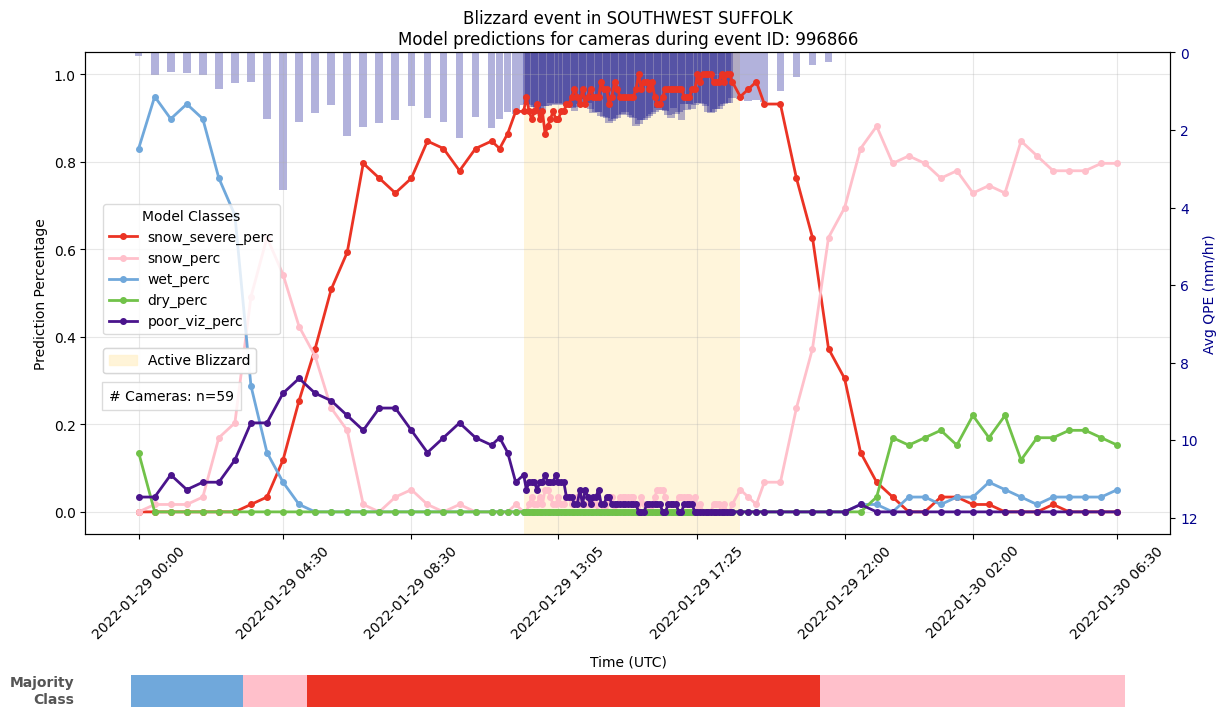

/tmp/tmp.YWNBFwUMnA/ipykernel_292582/2461802813.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')


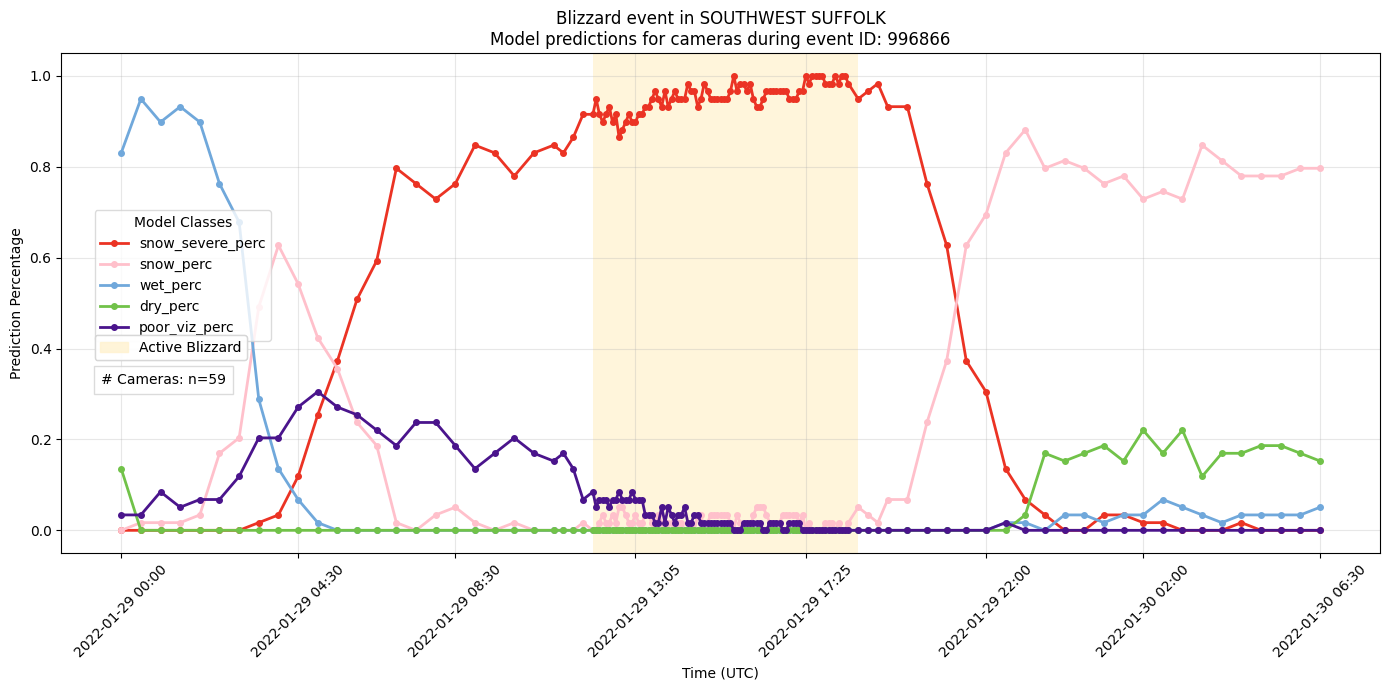

In [23]:
eventtoplot = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==996866]

plot_with_QPE(eventtoplot)
plot_no_QPE(eventtoplot)

In [ ]:
# Investigation 1b:  Maybe it turned into a winter storm warning after?? Look at the df by location and time (dont just zoom into the blizzard event)

# it didn't appear to turn into anything else after it. However, that doesn't mean that can't happen -- something to look into / organize

# go back to main df and grab that location | wfo
exb = stats_wpreds_allinfo[((stats_wpreds_allinfo["location"] == "SOUTHWEST SUFFOLK" ) & (stats_wpreds_allinfo["wfo"]=="OKX"))].sort_values("timestamp")

print(len(exb))
exb[75:100]

# Example 2: Lake effect snow - jumpy

In [ ]:
# This example shouldn't be used bc it only has 14 cameras (on avg maybe less on certain times), not robust, really jumpy. For case studies keep to regions that have large number of cams

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1158057]

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]

plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# VERSION W QPE
# note that when we filter by cams w QPE, it's not always gonna be the same n number of cameras. Need some way to visualize, like look, there was no QPE at this time (except for one cam, which was dry, so the 100% looks shocking, but really it's just bc there was like no QPE then 



event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1158057]

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]

plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Example 3: Lake effect snow - prove why agg summaries/stats across events is not fruitful

In [ ]:

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1225430]

event_one_example.head(4)
event_one_example.tail(4)

In [ ]:
# what dates was this event
print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_before"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_after"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="Lake-Effect Snow"]["datetime"])) # Event ran from 1/29/22 1200 to 1/29/22 1830

# based on plots we really only need to run more dates after the event


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]


plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
unique_types = event_one_example['id_type'].unique()
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting Setup (Using subplots for better axis control)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ADD SHADING FIRST (ax1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    ax1.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- THE NEW QPE FEATURE: Top-Down Bars (ax2) ---
ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis

# Plot QPE as a bar chart. Width might need slight tweaking depending on your time step size
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.01, color='darkblue', alpha=0.3, label='Avg QPE', align='center')

# Invert the y-axis so the bars "hang" from the top
ax2.invert_yaxis()

# Set the limit of ax2 so the bars only take up the top 25-30% of the plot
# This ensures they don't crash into your prediction lines at the bottom
max_qpe = event_one_example['qpe_avg'].max()
ax2.set_ylim(max_qpe * 3.5, 0) # Adjust the 3.5 multiplier to make bars longer/shorter
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
# Bring ax1 to the front so lines stay visually on top of the hanging QPE bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Hide ax1 background so ax2 is visible underneath

columns_to_plot = catslist_perc # Assuming this is your list of 5 columns
for col in columns_to_plot:
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
ax1.set_title(f"Model Predictions & QPE for Event: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (Scaled)")
ax1.set_ylabel("Prediction Percentage")

# Create a dual legend on ax1
# Legend 1: Your prediction lines
line_legend = ax1.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
ax1.add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]
ax1.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7), title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) # Cleaner way to handle datetime x-ticks
plt.tight_layout()

plt.show()

In [ ]:
# Make it very clear that this is JUST the L-E event where we have cameras. 
# This specific example is really just to show how we can't just aggregate summaries/stats from NCEI events like we did with QPE/NYSM events... it's bc the regions are just too big, and we dont necessarily have cams where the LE is occuring, esp bc LE is so local. Thus, NCEI events are helpful but just for case studies honestly. The results shown above w/ QPE are really just showing the good verification results we got by doing statistical analyses on QPE data. 

# Just as ONE more step to confirm, Show WHERE the L-E actually is within the region by showing QPE, and show how we don't have cams there. 

In [ ]:
print(np.unique(stats_wpreds_allinfo.id_type))
# print(np.unique(stats_wpreds_allinfo[stats_wpreds_allinfo["id_type"]=='Lake-Effect Snow'][]))

Final plot for dissertation

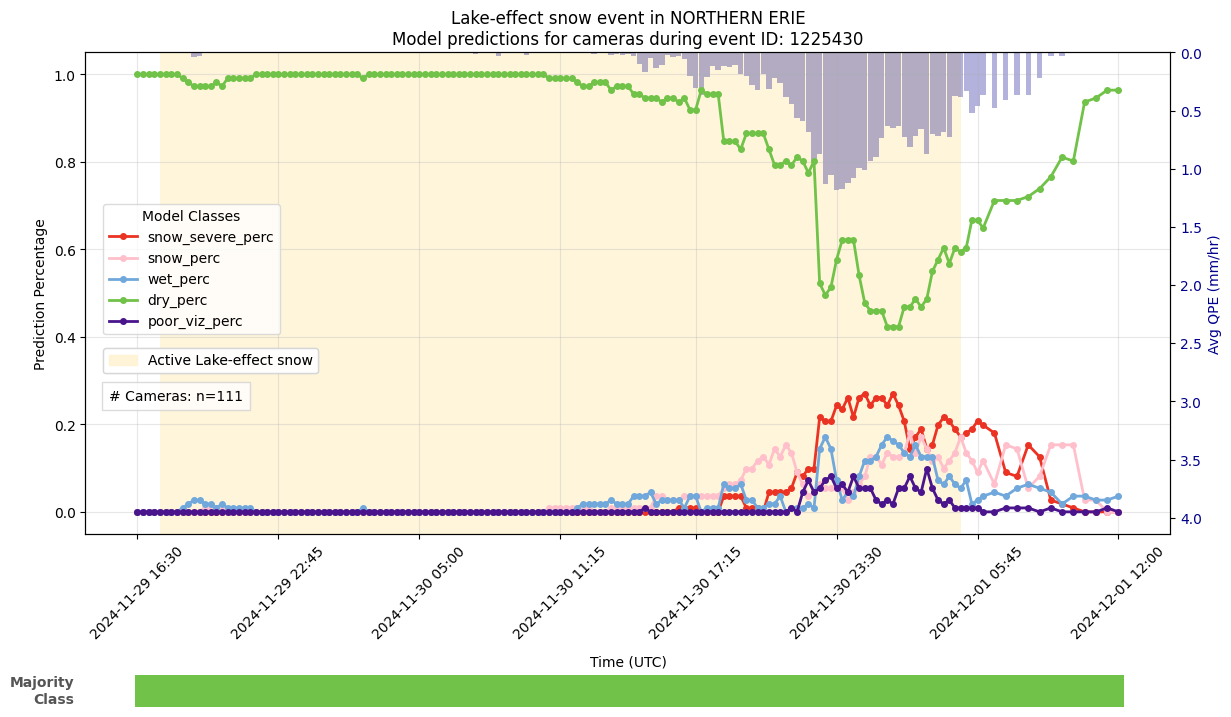

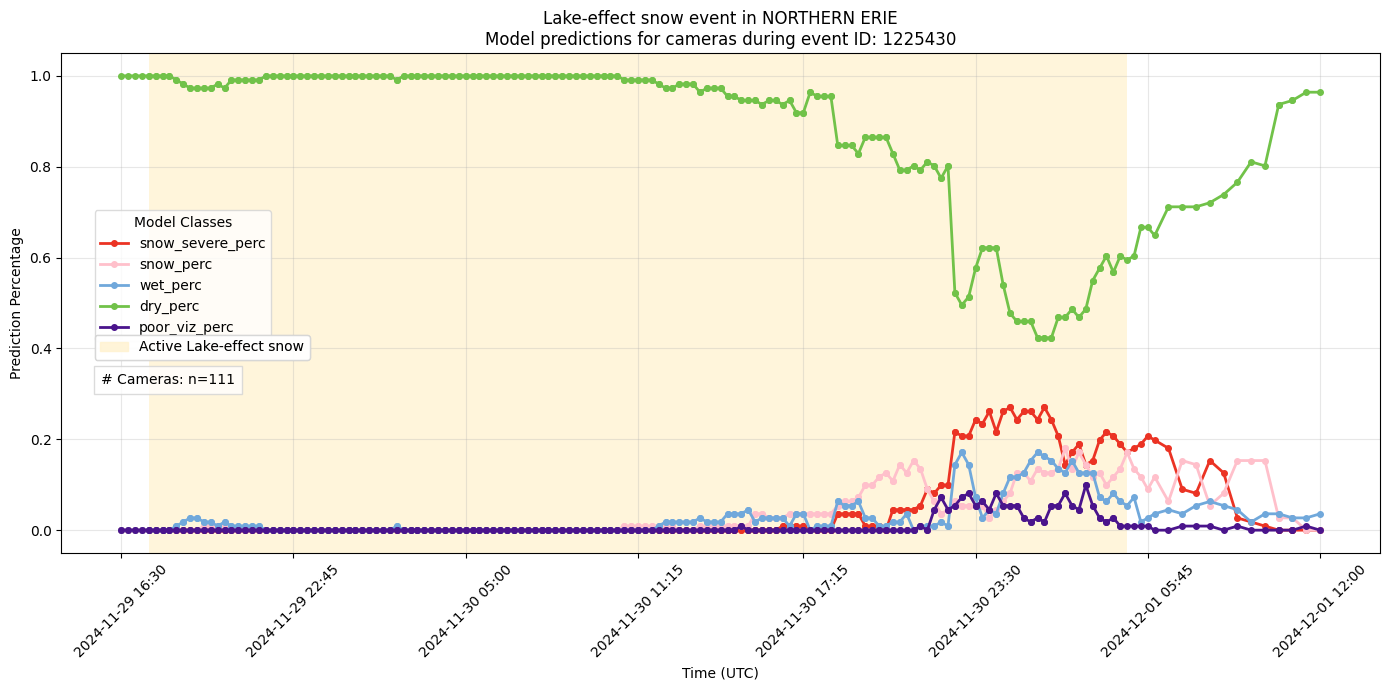

In [30]:
eventtoplot = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1225430]

# cut it off at dec 01 at 12Z 
target_index = (eventtoplot['datetime'] == '20241201_1200').idxmax()
eventtoplot = eventtoplot.loc[:target_index]

plot_with_QPE(eventtoplot)
plot_no_QPE(eventtoplot)

In [51]:
eventtoplot.head(4)

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,model_probs,prob_avg,model_qpe,qpe_avg,cat_counts,snow_severe,snow,wet,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep,datetime_plot
60552,1889,1225430,999,buffer_before,NORTHERN ERIE,BUF,20241129_1630,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...",{'dry': 111},"{""dry"": 0.877}",0.876829,{'dry': 0.0},0.0,"[0, 0, 0, 111, 0]",0,0,0,111,0,111,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.0,0.0,22977,2024-11-29 16:30:00
60555,1892,1225430,999,buffer_before,NORTHERN ERIE,BUF,20241129_1645,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...",{'dry': 111},"{""dry"": 0.87}",0.869626,{'dry': 0.0},0.0,"[0, 0, 0, 111, 0]",0,0,0,111,0,111,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.0,0.0,22983,2024-11-29 16:45:00
60558,1895,1225430,999,buffer_before,NORTHERN ERIE,BUF,20241129_1700,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...",{'dry': 111},"{""dry"": 0.872}",0.872488,{'dry': 0.0},0.0,"[0, 0, 0, 111, 0]",0,0,0,111,0,111,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.0,0.0,22993,2024-11-29 17:00:00
60561,1898,1225430,999,buffer_before,NORTHERN ERIE,BUF,20241129_1715,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6450', 'Skyline_6451', 'Skyline_6552...",{'dry': 111},"{""dry"": 0.873}",0.873300,{'dry': 0.0},0.0,"[0, 0, 0, 111, 0]",0,0,0,111,0,111,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.0,0.0,23012,2024-11-29 17:15:00


In [88]:
# To grab camera image examples for dissertation
import ast

filedate = "2024/11/30/20241130_0500"   #"2024/11/30/20241130_0500" "2024/12/01/20241201_0200"

# to grab a file
# eventtoplot[eventtoplot["datetime"]=="20241201_0200"]["modelfile"][25472]

# read in RSC
mf = pd.read_csv(f'/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/{filedate}/finalpreds.csv')
# mf.head(4)

# read in OBS

obsdf = pd.read_csv(f'/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_odm_3_ensembling/{filedate}/finalpreds.csv')
# obsdf.head(4)

obsdf = obsdf[["img_orig","select","select_prob"]]
obsdf = obsdf.rename(columns = {"select":"obs_select","select_prob":"obs_select_prob"})
dd = mf.merge(obsdf, how = "inner", on = "img_orig")

# subset to the sites for this event
sitesforevent = eventtoplot["sites"].iloc[0]
# print(sitesforevent)
sitesforevent = ast.literal_eval(sitesforevent)
# sitesforevent = sitesforevent.split(",") 
print(sitesforevent)
dd = dd[dd["site"].isin(sitesforevent)]

print("through dd")
display(dd)


# how many of these event are obs
display(dd.groupby(["obs_select"]).count())


# hrab severe snow examples 

severesnow = dd[dd["select"]=="snow_severe"]
dry = dd[dd["select"]=="dry"]

# display(severesnow.head(4))
# display(dry.head(4))


# USING THIS EXAMPLE, READIN IN IMAGES BELOW
severesnow_ex = severesnow["img_orig"].iloc[0]
severesnow_ex2 = severesnow["img_orig"].iloc[5]
dry_ex = dry["img_orig"].iloc[10]
dry_ex2 = dry["img_orig"].iloc[5]


# 11.0 miles, 17.7km apart!!
print(severesnow["Latitude"].iloc[0])
print(severesnow["Longitude"].iloc[0])
print(dry["Latitude"].iloc[10])
print(dry["Longitude"].iloc[10])

print(severesnow["Latitude"].iloc[5])
print(severesnow["Longitude"].iloc[5])
print(dry["Latitude"].iloc[5])
print(dry["Longitude"].iloc[5])

print(severesnow_ex)
# print(severesnow_ex2)
print(dry_ex)

# DURING EVENT WHEN SNOW PREDS OCCUR: 
# For reference they were iloc 0 for severe snow and iloc 10 for dry [code above]

# SEV SNOW - /home/csutter/cron/data/Skyline_6438/20241201/I_90_Between_Interchange_53_(I_190_Junction)_and_54_(Route_400)__Westbound__Skyline_6438_2024-12-01-01:58:41.jpg
# DRY - /home/csutter/cron/data/Skyline_6823/20241201/I_190_at_Interchange_18B__Northbound__Skyline_6823_2024-12-01-01:59:18.jpg
# SITE: Skyline_6438, and Skyline_6823
# SEV SNOW 2 - /home/csutter/cron/data/Skyline_6541/20241201/I_90_at_Interchange_52A_(William_Street)__Eastbound__Skyline_6541_2024-12-01-01:59:12.jpg
# DRY 2 - /home/csutter/cron/data/Skyline_6447/20241201/I_190_at_Interchange_13_(Austin_Street)__Northbound__Skyline_6447_2024-12-01-01:58:42.jpg

['Skyline_6450', 'Skyline_6451', 'Skyline_6552', 'Skyline_6550', 'Skyline_6549', 'Skyline_6553', 'Skyline_6447', 'Skyline_6448', 'Skyline_6449', 'Skyline_6452', 'Skyline_6453', 'Skyline_6823', 'Skyline_6454', 'Skyline_6505', 'Skyline_6456', 'Skyline_6455', 'Skyline_6506', 'Skyline_6507', 'Skyline_6508', 'Skyline_6545', 'Skyline_6554', 'Skyline_6547', 'Skyline_6546', 'Skyline_6548', 'Skyline_6723', 'Skyline_6457', 'Skyline_2139', 'Skyline_2141', 'Skyline_2143', 'Skyline_2145', 'Skyline_2147', 'Skyline_5628', 'Skyline_5631', 'Skyline_1828', 'Skyline_2140', 'Skyline_2138', 'Skyline_2142', 'Skyline_2144', 'Skyline_5630', 'Skyline_6496', 'Skyline_6539', 'Skyline_6438', 'Skyline_6440', 'Skyline_6444', 'Skyline_6445', 'Skyline_6536', 'Skyline_6722', 'Skyline_6537', 'Skyline_6498', 'Skyline_6542', 'Skyline_6497', 'Skyline_6541', 'Skyline_6540', 'Skyline_6437', 'Skyline_6543', 'Skyline_6544', 'Skyline_6439', 'Skyline_6441', 'Skyline_6442', 'Skyline_6443', 'Skyline_6446', 'Skyline_6538', 'Skylin

,Unnamed: 0,Unnamed: 0.2,Unnamed: 0.1,innerPhase_x,img_name,img_orig,site,img_cat,foldnum_x,timeofday,timeofevent,m0_calib_prob_dry,m0_calib_prob_poor_viz,m0_calib_prob_snow,m0_calib_prob_snow_severe,m0_calib_prob_wet,m0_calib_prob,img_orig_hrrr,innerPhase_y,foldnum_y,Latitude,Longitude,yr,mo,day,date,time,ymd,date_and_time_str,date_and_time_dt,date_and_time_dt_round,date_and_time_dt_init,init_hr,init_year,init_month,init_day,init_yyyymmdd,hrrr_file,HRRR_latlon,HRRR_distkm,time.1,valid_time,latitude,longitude,t2m,pt,sh2,d2m,r2,u10,v10,si10,asnow,tp,orog,cape,mslma,dswrf,dlwrf,tcc,gh,dpt,atmosphere,isobaricInhPa,uavg,o_prob_dry,o_prob_poor_viz,o_prob_snow,o_prob_snow_severe,o_prob_wet,o_pred,o_prob,classifier_TF,classifier_01,o_prob_calib,m0_calib_pred,m1_calib_prob_wet,m1_calib_prob_dry,m1_calib_prob_snow,m1_calib_prob_snow_severe,m1_calib_prob_poor_viz,m1_calib_prob,m1_calib_pred,m2_calib_prob_wet,m2_calib_prob_dry,m2_calib_prob_snow,m2_calib_prob_snow_severe,m2_calib_prob_poor_viz,m2_calib_prob,m2_calib_pred,m3_calib_prob_wet,m3_calib_prob_dry,m3_calib_prob_snow,m3_calib_prob_snow_severe,m3_calib_prob_poor_viz,m3_calib_prob,m3_calib_pred,m4_calib_prob_wet,m4_calib_prob_dry,m4_calib_prob_snow,m4_calib_prob_snow_severe,m4_calib_prob_poor_viz,m4_calib_prob,m4_calib_pred,list_5preds,list_5probs,dict_catAsKeys_modelAsValues,dict_catAsKeys_countAsValues,dict_catAsKeys_probsAsValues,dict_mostConfident_singleModel,ensembleAvg_dry,ensembleAvg_snow,ensembleAvg_snow_severe,ensembleAvg_wet,ensembleAvg_poor_viz,ensembleAvg_pred,ensembleAvg_predprob,ensembleMode_pred,ensembleMaxConf_pred,methodalign_1_2,methodalign_1_3,methodalign_2_3,select,decision,select_prob,select_correct,ok_select,num_models_pred_cat,conf_consist,conf_probability,conf_overall,confidence,Lon_360,qpe_val,precip_flag,precip_class,obs_select,obs_select_prob
373,373,97,97,innerTrain,I_190_Junction_of_I_190_and_I_290_View_1__Unkn...,/home/csutter/cron/data/Skyline_6450/20241130/...,Skyline_6450,dry,0,night,{Timestamp('2024-11-30 11:54:35.485727'): 'daw...,0.864865,0.000425,0.012699,0.000268,0.121742,0.864865,/home/csutter/cron/data/Skyline_6450/20241130/...,innerTrain,0,42.987600,-78.913900,2024,11,30,20241130,05:00:35,20241130,05:00:35 20241130,2024-11-30 05:00:35,2024-11-30 05:00:00,2024-11-30 03:00:00,3,2024,11,30,20241130,/home/csutter/AI2ES/cleaned/HRRR/2024/11/20241...,"[42.97634357430433, -78.92728121981867]",1.659817,2024-11-30 03:00:00,2024-11-30 05:00:00,42.976344,-78.927281,269.8745,270.68152,0.00217,265.4998,67.1,5.227458,1.563638,5.508166,0.0,0.0,182.76340,0.0,101298.0,0.0,202.8,14.0,5251.3345,232.74918,0.0,500.0,5.456306,0.842437,0.000496,0.014807,0.000313,0.141948,dry,0.842437,True,1,0.864865,dry,0.050907,0.941982,0.007057,0.000054,0.000000,0.941982,dry,0.282548,0.657895,0.059377,0.000181,0.000000,0.657895,dry,0.329617,0.595745,0.053645,0.002749,0.018244,0.595745,dry,0.119159,0.850000,0.025181,0.000000,0.005660,0.850000,dry,"['dry', 'dry', 'dry', 'dry', 'dry']","[0.8648648648648649, 0.9419822723609992, 0.657...","{'dry': ['m0', 'm1', 'm2', 'm3', 'm4']}",{'dry': 5},{'dry': 0.7820973109838066},{'dry': 0.9419822723609992},0.782097,0.031592,0.000650,0.180795,0.004866,dry,0.782097,dry,dry,True,True,True,dry,align_avg_mode,0.782097,True,True,5,3,2,2.5,high,281.086100,0.0,0.0,No Precip,nonobs,0.930796
374,374,1430,1430,innerTrain,I_190_Junction_of_I_190_and_I_290_View_2__Unkn...,/home/csutter/cron/data/Skyline_6451/20241130/...,Skyline_6451,dry,0,night,{Timestamp('2024-11-30 11:54:35.485727'): 'daw...,0.864865,0.002833,0.013292,0.000042,0.118968,0.864865,/home/csutter/cron/data/Skyline_6451/20241130/...,innerTrain,0,42.987600,-78.913900,2024,11,30,20241130,05:00:36,20241130,05:00:36 20241130,2024-11-30 05:00:36,2024-11-30 05:00:00,2024-11-30 03:00:00,3,2024,11,30,20241130,/home/csutter/AI2ES/cleaned/HRRR/2024/11/20241...,"[42.97634357430433, -78.92728121981867]",1.659817,2024-11-30 03:00:00,2024-11-30 05:00:00,42.976344,-78.927281,269.8745,270.68152,0.00217,265.49

,Unnamed: 0,Unnamed: 0.2,Unnamed: 0.1,innerPhase_x,img_name,img_orig,site,img_cat,foldnum_x,timeofday,timeofevent,m0_calib_prob_dry,m0_calib_prob_poor_viz,m0_calib_prob_snow,m0_calib_prob_snow_severe,m0_calib_prob_wet,m0_calib_prob,img_orig_hrrr,innerPhase_y,foldnum_y,Latitude,Longitude,yr,mo,day,date,time,ymd,date_and_time_str,date_and_time_dt,date_and_time_dt_round,date_and_time_dt_init,init_hr,init_year,init_month,init_day,init_yyyymmdd,hrrr_file,HRRR_latlon,HRRR_distkm,time.1,valid_time,latitude,longitude,t2m,pt,sh2,d2m,r2,u10,v10,si10,asnow,tp,orog,cape,mslma,dswrf,dlwrf,tcc,gh,dpt,atmosphere,isobaricInhPa,uavg,o_prob_dry,o_prob_poor_viz,o_prob_snow,o_prob_snow_severe,o_prob_wet,o_pred,o_prob,classifier_TF,classifier_01,o_prob_calib,m0_calib_pred,m1_calib_prob_wet,m1_calib_prob_dry,m1_calib_prob_snow,m1_calib_prob_snow_severe,m1_calib_prob_poor_viz,m1_calib_prob,m1_calib_pred,m2_calib_prob_wet,m2_calib_prob_dry,m2_calib_prob_snow,m2_calib_prob_snow_severe,m2_calib_prob_poor_viz,m2_calib_prob,m2_calib_pred,m3_calib_prob_wet,m3_calib_prob_dry,m3_calib_prob_snow,m3_calib_prob_snow_severe,m3_calib_prob_poor_viz,m3_calib_prob,m3_calib_pred,m4_calib_prob_wet,m4_calib_prob_dry,m4_calib_prob_snow,m4_calib_prob_snow_severe,m4_calib_prob_poor_viz,m4_calib_prob,m4_calib_pred,list_5preds,list_5probs,dict_catAsKeys_modelAsValues,dict_catAsKeys_countAsValues,dict_catAsKeys_probsAsValues,dict_mostConfident_singleModel,ensembleAvg_dry,ensembleAvg_snow,ensembleAvg_snow_severe,ensembleAvg_wet,ensembleAvg_poor_viz,ensembleAvg_pred,ensembleAvg_predprob,ensembleMode_pred,ensembleMaxConf_pred,methodalign_1_2,methodalign_1_3,methodalign_2_3,select,decision,select_prob,select_correct,ok_select,num_models_pred_cat,conf_consist,conf_probability,conf_overall,confidence,Lon_360,qpe_val,precip_flag,precip_class,obs_select_prob
obs_select,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
nonobs,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85
obs,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26


IndexError: single positional indexer is out-of-bounds

In [86]:
print(severesnow_ex2)
print(dry_ex2)


/home/csutter/cron/data/Skyline_6541/20241201/I_90_at_Interchange_52A_(William_Street)__Eastbound__Skyline_6541_2024-12-01-01:59:12.jpg
/home/csutter/cron/data/Skyline_6447/20241201/I_190_at_Interchange_13_(Austin_Street)__Northbound__Skyline_6447_2024-12-01-01:58:42.jpg


/home/csutter/cron/data/Skyline_6438/20241130/I_90_Between_Interchange_53_(I_190_Junction)_and_54_(Route_400)__Westbound__Skyline_6438_2024-11-30-05:00:33.jpg
/home/csutter/cron/data/Skyline_6823/20241130/I_190_at_Interchange_18B__Northbound__Skyline_6823_2024-11-30-05:00:59.jpg
/home/csutter/cron/data/Skyline_6541/20241130/I_90_at_Interchange_52A_(William_Street)__Eastbound__Skyline_6541_2024-11-30-05:00:54.jpg
/home/csutter/cron/data/Skyline_6447/20241130/I_190_at_Interchange_13_(Austin_Street)__Northbound__Skyline_6447_2024-11-30-05:00:35.jpg


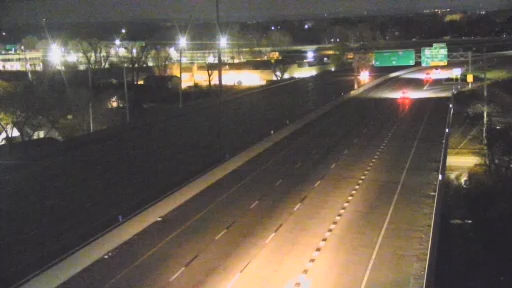

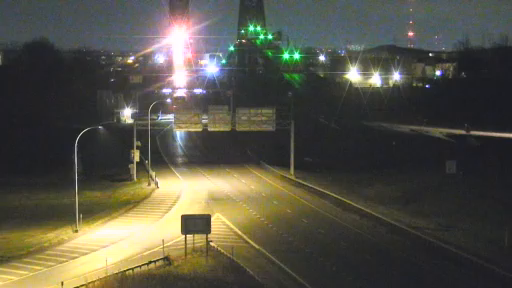

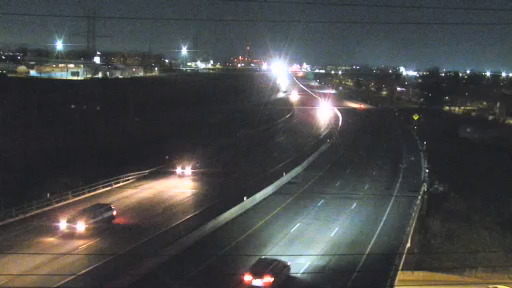

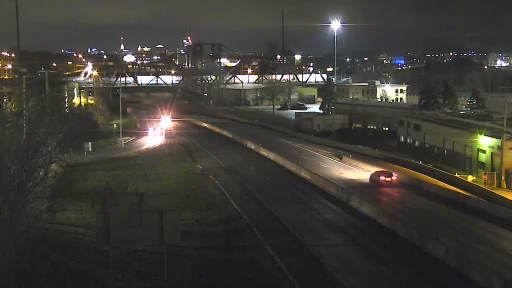

In [90]:
# to find the equivalent images at an earlier time, re-run all this code (in the cell above) but change the datetime at the top (which may error with indexing which is fine bc not actually taking exampels from that time), AND THEN can run everything below

drynow_snowlater = dd[dd["site"]=="Skyline_6438"]["img_orig"].item()
drynow_drylater = dd[dd["site"]=="Skyline_6823"]["img_orig"].item()

print(drynow_snowlater)
print(drynow_drylater)

drynow_snowlater2 = dd[dd["site"]=="Skyline_6541"]["img_orig"].item()
drynow_drylater2 = dd[dd["site"]=="Skyline_6447"]["img_orig"].item()

print(drynow_snowlater2)
print(drynow_drylater2)


# EQUIVALENT IMAGE AT THE 11/30 5Z TIME WHEN 100% DRY PREDS

img = Image.open(drynow_snowlater)
img.show() 

img = Image.open(drynow_drylater)
img.show() 


img = Image.open(drynow_snowlater2)
img.show() 

img = Image.open(drynow_drylater2)
img.show() 



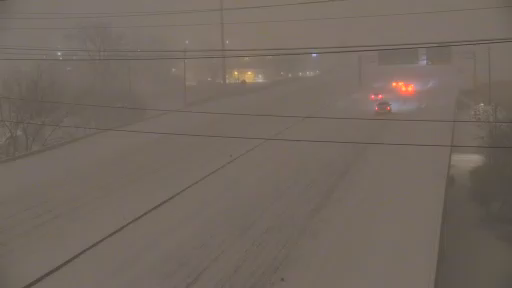

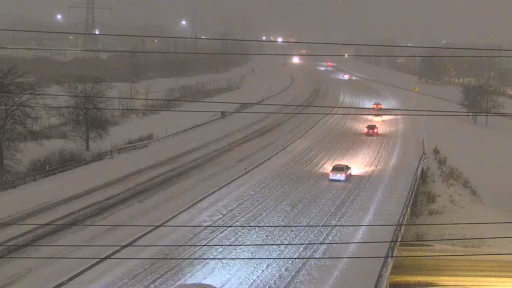

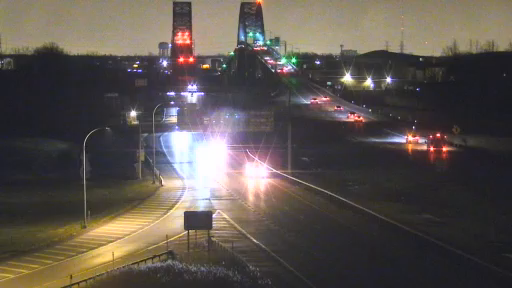

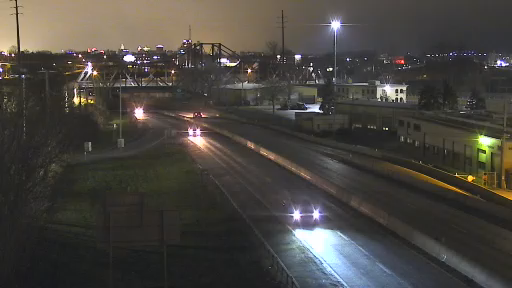

In [87]:
from PIL import Image




# AT THE 12/1 TIME WHEN SEVERE SNOW STARTS HAPPENING

# img = Image.open(severesnow_ex)
# img.show() 

# img = Image.open(severesnow_ex2)
# img.show() 

# img = Image.open(dry_ex)
# img.show() 

# img = Image.open(dry_ex2)
# img.show() 






# Example 3b: Lake effect 1233926 - 'better' example, but still see previous example

In [ ]:
event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1233926]

event_one_example.head(4)

In [ ]:
# Grab basic info for reference

print(np.unique(event_one_example["id_type"]))

# what dates was this event
print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_before"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_after"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="Lake-Effect Snow"]["datetime"])) # Event ran from 1/29/22 1200 to 1/29/22 1830

### What more buffer times do we want



In [ ]:
print(event_one_example['datetime_plot'].value_counts().head())

In [ ]:
event_one_example[event_one_example["datetime"]=="20250120_1200"]

In [ ]:
print(len(event_one_example))
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])
print(len(event_one_example))

In [ ]:



# event_one_example.head(4)
# event_one_example.tail(4)



import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
unique_types = event_one_example['id_type'].unique()
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting Setup (Using subplots for better axis control)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ADD SHADING FIRST (ax1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    ax1.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- THE NEW QPE FEATURE: Top-Down Bars (ax2) ---
ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis

# Plot QPE as a bar chart. Width might need slight tweaking depending on your time step size
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.01, color='darkblue', alpha=0.3, label='Avg QPE', align='center')

# Invert the y-axis so the bars "hang" from the top
ax2.invert_yaxis()

# Set the limit of ax2 so the bars only take up the top 25-30% of the plot
# This ensures they don't crash into your prediction lines at the bottom
max_qpe = event_one_example['qpe_avg'].max()
ax2.set_ylim(max_qpe * 3.5, 0) # Adjust the 3.5 multiplier to make bars longer/shorter
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
# Bring ax1 to the front so lines stay visually on top of the hanging QPE bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Hide ax1 background so ax2 is visible underneath

columns_to_plot = catslist_perc # Assuming this is your list of 5 columns
for col in columns_to_plot:
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
ax1.set_title(f"Model Predictions & QPE for Event: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (Scaled)")
ax1.set_ylabel("Prediction Percentage")

# Create a dual legend on ax1
# Legend 1: Your prediction lines
line_legend = ax1.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
ax1.add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]
ax1.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7), title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) # Cleaner way to handle datetime x-ticks
plt.tight_layout()

plt.show()

Final plot for dissertation

In [29]:
eventtoplot = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1233926]
eventtoplot.head(3)

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
62635,3972,1233926,999,buffer_before,MONROE,BUF,20250119_2100,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8279', 'Skyline_8279', 'Skyline_8281...","{'dry': 342, 'snow': 2, 'snow_severe': 2}",...,342,0,346,"[0.0058, 0.0058, 0.0, 0.9884, 0.0]",0.0058,0.0058,0.0000,0.9884,0.0,44137
62636,3973,1233926,999,buffer_before,MONROE,BUF,20250119_2130,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8279', 'Skyline_8279', 'Skyline_8281...","{'dry': 116, 'snow': 100, 'wet': 130}",...,116,0,346,"[0.0, 0.289, 0.3757, 0.3353, 0.0]",0.0000,0.2890,0.3757,0.3353,0.0,44188
61199,2536,1233926,999,buffer_before,MONROE,BUF,20250119_2200,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_8279', 'Skyline_8279', 'Skyline_8281...","{'dry': 92, 'snow': 96, 'snow_severe': 2, 'wet...",...,92,0,346,"[0.0058, 0.2775, 0.4509, 0.2659, 0.0]",0.0058,0.2775,0.4509,0.2659,0.0,44250


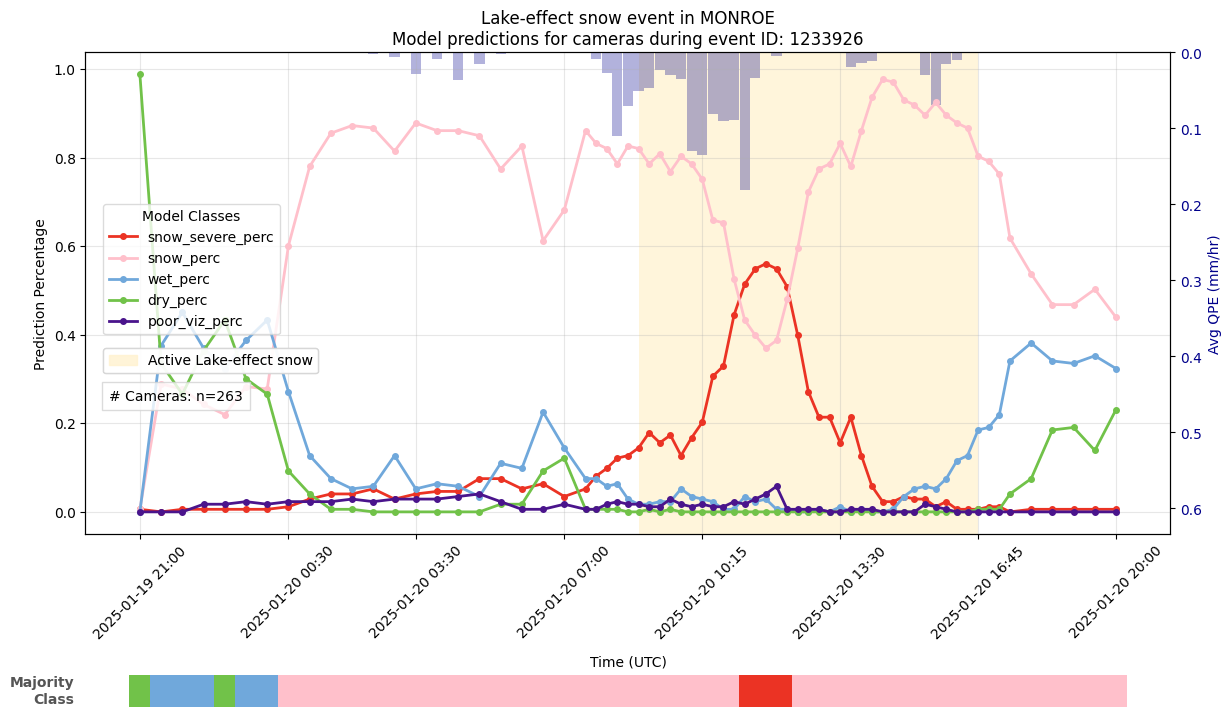

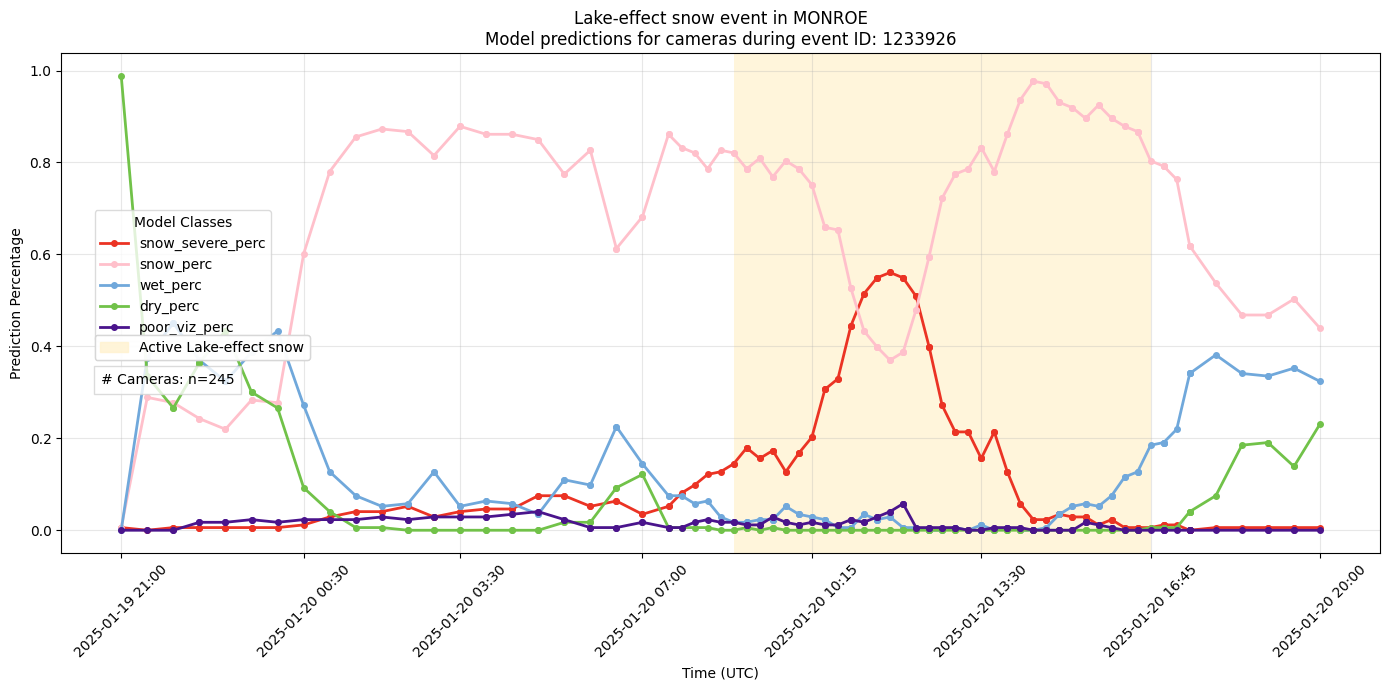

In [29]:
eventtoplot = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1233926]

# cut it off after buffer
target_index = (eventtoplot['datetime'] == '20250120_2000').idxmax()
eventtoplot = eventtoplot.loc[:target_index]

plot_with_QPE(eventtoplot)
plot_no_QPE(eventtoplot)

In [ ]:
# consider lumping together snow and severe snow, as the story will be cleaner to tell I think, rather than having to fixate on the "dips"
# Or maybe inspect some of these cams to see/
# not sure we want QPE up here for all the case study analyses... it's more to explain and not sure it's needed for the story BESIDES that one example above to show why we cant just aggregate across events and assume LE shows severe snow

# Example 4: Winter weather

In [ ]:
# TOO FEW NUMBER OF CAMS, dont use

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1152731]

# event_one_example.head(4)
# event_one_example.tail(4)



import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
unique_types = event_one_example['id_type'].unique()
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting Setup (Using subplots for better axis control)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ADD SHADING FIRST (ax1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    ax1.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- THE NEW QPE FEATURE: Top-Down Bars (ax2) ---
ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis

# Plot QPE as a bar chart. Width might need slight tweaking depending on your time step size
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.009, color='darkblue', alpha=0.3, label='Avg QPE', align='center')

# Invert the y-axis so the bars "hang" from the top
ax2.invert_yaxis()

# Set the limit of ax2 so the bars only take up the top 25-30% of the plot
# This ensures they don't crash into your prediction lines at the bottom
max_qpe = event_one_example['qpe_avg'].max()
ax2.set_ylim(max_qpe * 3.5, 0) # Adjust the 3.5 multiplier to make bars longer/shorter
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
# Bring ax1 to the front so lines stay visually on top of the hanging QPE bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Hide ax1 background so ax2 is visible underneath

columns_to_plot = catslist_perc # Assuming this is your list of 5 columns
for col in columns_to_plot:
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
ax1.set_title(f"Model Predictions & QPE for Event: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (Scaled)")
ax1.set_ylabel("Prediction Percentage")

# Create a dual legend on ax1
# Legend 1: Your prediction lines
line_legend = ax1.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
ax1.add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]
ax1.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7), title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) # Cleaner way to handle datetime x-ticks
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- ADDED .copy() to prevent the Pandas warning ---
event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1152731].copy()

locdesc = list(event_one_example["id_loc"].unique())[0]

# 1. Convert, Drop Duplicates, and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Figure and Primary Axis (ax1)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- THE FIX: Create ax2 early so both Shading and QPE can be drawn on it ---
ax2 = ax1.twinx() 

# Grab event name for shading
unique_types = event_one_example['id_type'].unique()
eventtype = [i for i in unique_types if i not in ["buffer_before", "buffer_after"]][0]
active_event_string = eventtype 

# --- ADD SHADING FIRST (Drawn on ax2, pushed to the back with zorder=1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    if etype == active_event_string:
        # Changed from ax1 to ax2!
        ax2.axvspan(start, end, color='#fff2cc', alpha=0.7, lw=0, zorder=1)

# --- THE QPE FEATURE: Top-Down Bars (Drawn on ax2, overlapping shading with zorder=2) ---
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.01, color='darkblue', alpha=0.3, label='Avg QPE', align='center', zorder=2)

ax2.invert_yaxis()
max_qpe = event_one_example['qpe_avg'].max()
if max_qpe == 0: max_qpe = 1 
ax2.set_ylim(max_qpe * 3.5, 0) 
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) 

columns_to_plot = catslist_perc
for col in columns_to_plot:
    line_color = custom_colors.get(col, 'gray') 
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, color=line_color, marker='o', markersize=4, linewidth=2)

# 3. Formatting
ax1.set_title(f"{active_event_string.capitalize()} event in {locdesc}\nModel predictions for cameras during event ID: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Prediction Percentage")

# --- UNIFIED STYLING AND STACKING ---
legend_style = {'facecolor': 'white', 'framealpha': 0.8, 'edgecolor': 'lightgray'}

# Legend 1
line_legend = ax1.legend(loc='upper left', title="Model Classes", bbox_to_anchor=(0.02, 0.7), **legend_style)
line_legend.set_zorder(10) # <-- Bulletproof fix so it never disappears
ax1.add_artist(line_legend)

# Legend 2
event_patch = [mpatches.Patch(color='#fff2cc', alpha=0.7, label=f'Active {active_event_string.capitalize()}')]
event_legend = ax1.legend(handles=event_patch, loc='upper left', bbox_to_anchor=(0.02, 0.44), **legend_style)
event_legend.set_zorder(10) # <-- Bulletproof fix
ax1.add_artist(event_legend)

# Text Box: Avg Cameras 
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    0.032, 0.35, 
    f"# Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='left', 
    bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=10,
    zorder=10 # <-- Bulletproof fix so it never gets buried behind the axes
)

# Final Cleanup
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) 
plt.tight_layout()

plt.show()

# Example 4b: Winter weather ALY

In [ ]:

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1236425]


# Grab basic info for reference

print(np.unique(event_one_example["id_type"]))
display(event_one_example.head(3))
# what dates was this event
print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_before"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_after"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="Winter Weather"]["datetime"])) # Event ran from 1/29/22 1200 to 1/29/22 1830

### What more buffer times do we want



In [ ]:


# TOO FEW NUMBER OF CAMS, dont use

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1236425]

# event_one_example.head(4)
# event_one_example.tail(4)



import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
unique_types = event_one_example['id_type'].unique()
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting Setup (Using subplots for better axis control)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ADD SHADING FIRST (ax1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    ax1.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- THE NEW QPE FEATURE: Top-Down Bars (ax2) ---
ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis

# Plot QPE as a bar chart. Width might need slight tweaking depending on your time step size
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.009, color='darkblue', alpha=0.3, label='Avg QPE', align='center')

# Invert the y-axis so the bars "hang" from the top
ax2.invert_yaxis()

# Set the limit of ax2 so the bars only take up the top 25-30% of the plot
# This ensures they don't crash into your prediction lines at the bottom
max_qpe = event_one_example['qpe_avg'].max()
ax2.set_ylim(max_qpe * 3.5, 0) # Adjust the 3.5 multiplier to make bars longer/shorter
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
# Bring ax1 to the front so lines stay visually on top of the hanging QPE bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Hide ax1 background so ax2 is visible underneath

columns_to_plot = catslist_perc # Assuming this is your list of 5 columns
for col in columns_to_plot:
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
ax1.set_title(f"Model Predictions & QPE for Event: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (Scaled)")
ax1.set_ylabel("Prediction Percentage")

# Create a dual legend on ax1
# Legend 1: Your prediction lines
line_legend = ax1.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
ax1.add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]
ax1.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7), title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) # Cleaner way to handle datetime x-ticks
plt.tight_layout()

plt.show()

For dissertation

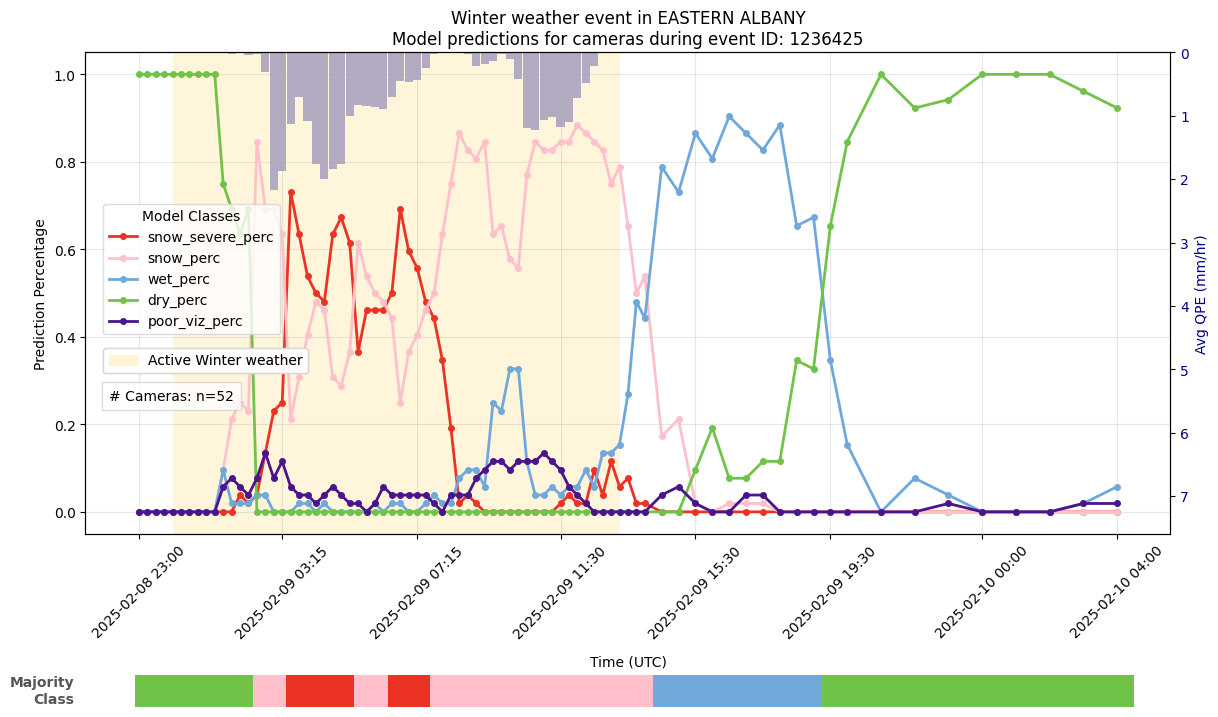

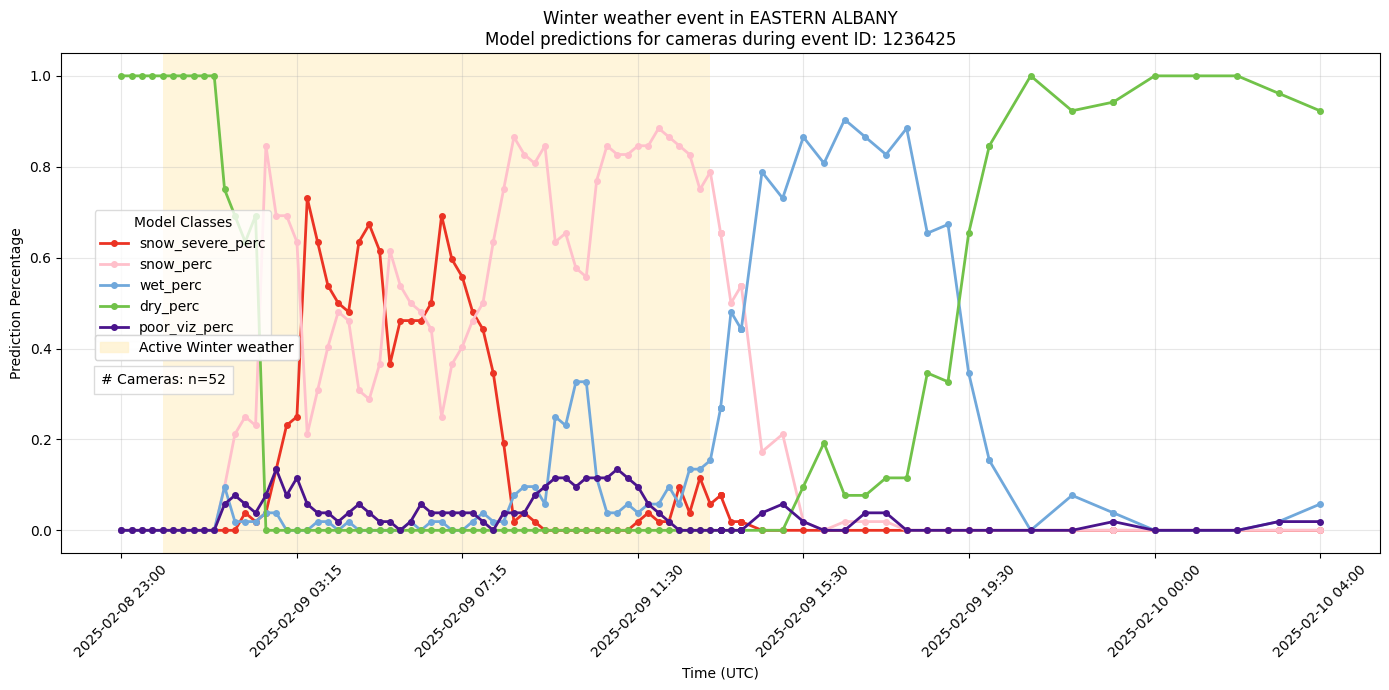

In [28]:
eventtoplot = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1236425]

# cut it off after buffer
target_index = (eventtoplot['datetime'] == '20250210_0400').idxmax()
eventtoplot = eventtoplot.loc[:target_index]

plot_with_QPE(eventtoplot)
plot_no_QPE(eventtoplot)

In [ ]:
# Winter weather example. This one is good bc of the sudden drop in dry from 100% of cam predictions being dry to not dry. Can see the mix of snow and severe snow, then toward the end see wet picking up (maybe plows got through?, why that increase in green at 2/9 10). See wet pick up more definitively in the end buffer

In [73]:
eventtoplot.head(4)

# grab the episode id (id_ep) to see if it's the same as the BGM case below, and also to see if it's a good candidate for a statewide plot

print(np.unique(eventtoplot["id_ep"])) # have to look at the non buffers


[   999 199727]


# Example 5: Winter storm

In [ ]:

event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1163963]





# event_one_example.head(4)
# event_one_example.tail(4)



import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
unique_types = event_one_example['id_type'].unique()
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting Setup (Using subplots for better axis control)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ADD SHADING FIRST (ax1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    ax1.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- THE NEW QPE FEATURE: Top-Down Bars (ax2) ---
ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis

# Plot QPE as a bar chart. Width might need slight tweaking depending on your time step size
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.009, color='darkblue', alpha=0.3, label='Avg QPE', align='center')

# Invert the y-axis so the bars "hang" from the top
ax2.invert_yaxis()

# Set the limit of ax2 so the bars only take up the top 25-30% of the plot
# This ensures they don't crash into your prediction lines at the bottom
max_qpe = event_one_example['qpe_avg'].max()
ax2.set_ylim(max_qpe * 3.5, 0) # Adjust the 3.5 multiplier to make bars longer/shorter
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
# Bring ax1 to the front so lines stay visually on top of the hanging QPE bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Hide ax1 background so ax2 is visible underneath

columns_to_plot = catslist_perc # Assuming this is your list of 5 columns
for col in columns_to_plot:
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
ax1.set_title(f"Model Predictions & QPE for Event: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (Scaled)")
ax1.set_ylabel("Prediction Percentage")

# Create a dual legend on ax1
# Legend 1: Your prediction lines
line_legend = ax1.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
ax1.add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]
ax1.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7), title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) # Cleaner way to handle datetime x-ticks
plt.tight_layout()

plt.show()

# Example 5b: Winter storm BGM

In [ ]:
event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1234744]

display(event_one_example.head(4))

# Grab basic info for reference

print(np.unique(event_one_example["id_type"]))
display(event_one_example.head(3))
# what dates was this event
print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_before"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="buffer_after"]["datetime"]))

print(np.unique(event_one_example[event_one_example["id_type"]=="Winter Storm"]["datetime"])) # Event ran from 1/29/22 1200 to 1/29/22 1830

### What more buffer times do we want



In [ ]:
# 1159174 
# 1159174



event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1234744]





# event_one_example.head(4)
# event_one_example.tail(4)



import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.drop_duplicates(subset=['datetime_plot'])

event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

print("Average")
avg_n = int(event_one_example['totalcams'].mean())
print(avg_n)

# 2. Setup Shading Colors
unique_types = event_one_example['id_type'].unique()
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting Setup (Using subplots for better axis control)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ADD SHADING FIRST (ax1) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    ax1.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- THE NEW QPE FEATURE: Top-Down Bars (ax2) ---
ax2 = ax1.twinx() # Create a secondary y-axis sharing the same x-axis

# Plot QPE as a bar chart. Width might need slight tweaking depending on your time step size
ax2.bar(event_one_example['datetime_plot'], event_one_example['qpe_avg'], 
        width=0.009, color='darkblue', alpha=0.3, label='Avg QPE', align='center')

# Invert the y-axis so the bars "hang" from the top
ax2.invert_yaxis()

# Set the limit of ax2 so the bars only take up the top 25-30% of the plot
# This ensures they don't crash into your prediction lines at the bottom
max_qpe = event_one_example['qpe_avg'].max()
ax2.set_ylim(max_qpe * 3.5, 0) # Adjust the 3.5 multiplier to make bars longer/shorter
ax2.set_ylabel("Avg QPE (mm/hr)", color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# --- PLOT YOUR 5 COLUMNS (ax1) ---
# Bring ax1 to the front so lines stay visually on top of the hanging QPE bars
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False) # Hide ax1 background so ax2 is visible underneath

columns_to_plot = catslist_perc # Assuming this is your list of 5 columns
for col in columns_to_plot:
    ax1.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
ax1.set_title(f"Model Predictions & QPE for Event: {event_one_example['id_event'].iloc[0]}")
ax1.set_xlabel("Time (Scaled)")
ax1.set_ylabel("Prediction Percentage")

# Create a dual legend on ax1
# Legend 1: Your prediction lines
line_legend = ax1.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
ax1.add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]
ax1.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7), title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())
ax1.text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=ax1.transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45) # Cleaner way to handle datetime x-ticks
plt.tight_layout()

plt.show()

For dissertation

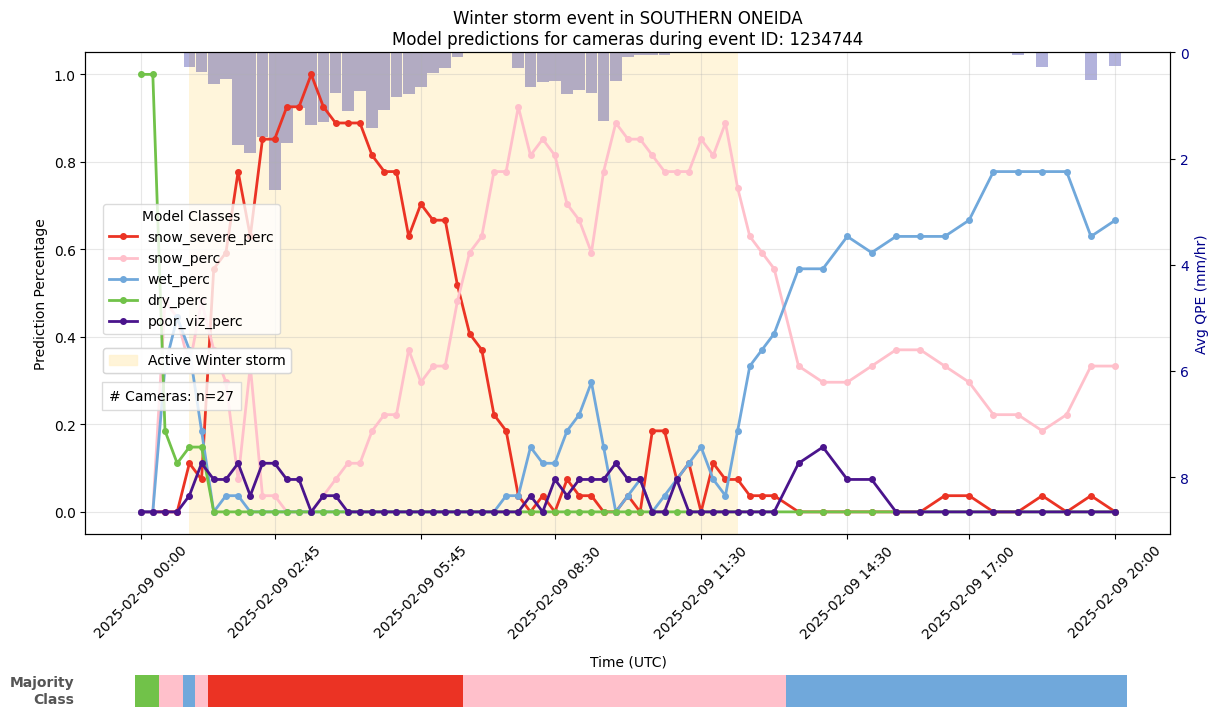

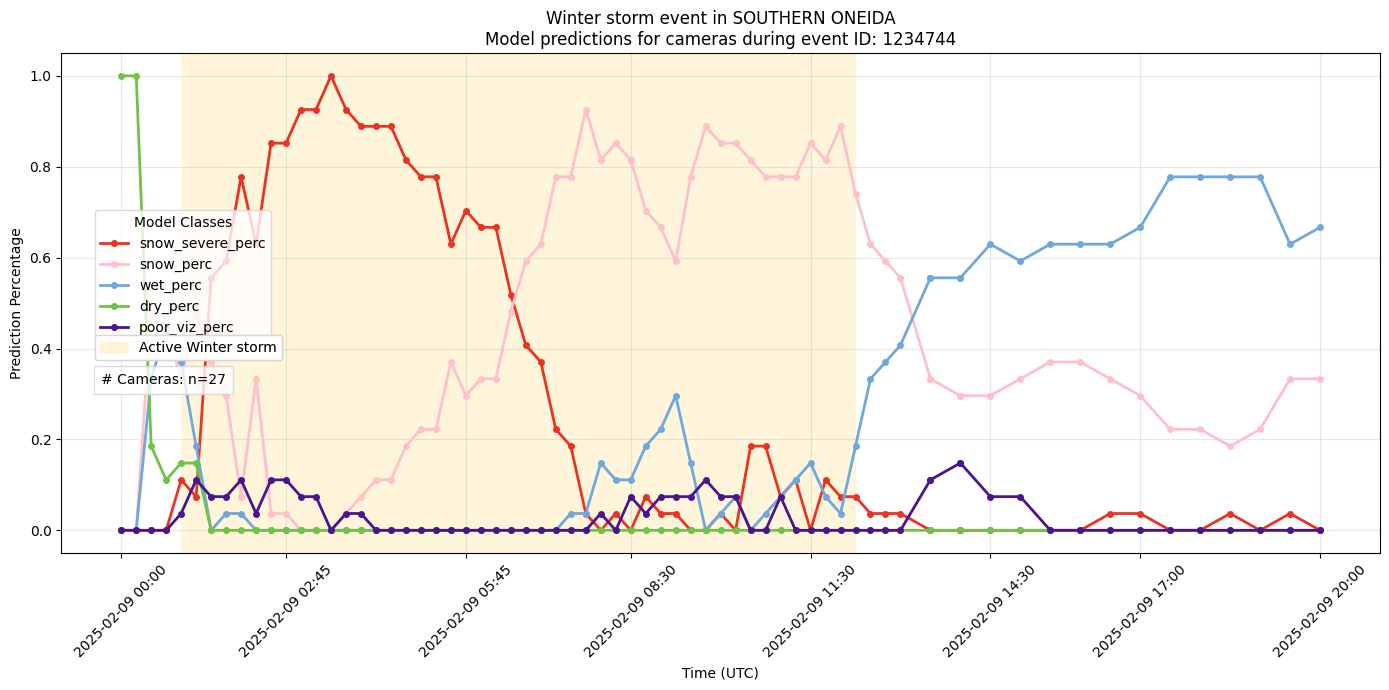

In [27]:
eventtoplot = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1234744]

# cut it off after buffer
target_index = (eventtoplot['datetime'] == '20250209_2000').idxmax()
eventtoplot = eventtoplot.loc[:target_index]

plot_with_QPE(eventtoplot)
plot_no_QPE(eventtoplot)

In [ ]:
# Winter storm
# Binghamton

# Note that this is actually the same dates as the albany winter weather. A great example (hopefully where they were identified from the same system!) where diff levels of events and different / regions! End time is a tad earlier here bc BGM western of ALY


In [75]:
print(np.unique(eventtoplot["id_ep"])) # have to look at the non buffers


[   999 199623]


# Statewide event

In [ ]:
# ultimately see /home/csutter/DRIVE-clean/weather_events/notebooks/statewide_event_gif.ipynb for this work

In [ ]:
# but keeping reference work below.. [ did not end up finding statewide events this way just did from googling major events ]

In [76]:
# find an epidsode id that had the largest # of unqiue event ids (which represent different effected regions)

stats_wpreds_allinfo.head(4)

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
62558,3895,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_0000,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...","{'dry': 8, 'poor_viz': 2, 'wet': 49}",...,8,2,59,"[0.0, 0.0, 0.8305, 0.1356, 0.0339]",0.0,0.0000,0.8305,0.1356,0.0339,1
62559,3896,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_0030,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...","{'poor_viz': 2, 'snow': 1, 'wet': 56}",...,0,2,59,"[0.0, 0.0169, 0.9492, 0.0, 0.0339]",0.0,0.0169,0.9492,0.0000,0.0339,2
62560,3897,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_0100,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...","{'poor_viz': 5, 'snow': 1, 'wet': 53}",...,0,5,59,"[0.0, 0.0169, 0.8983, 0.0, 0.0847]",0.0,0.0169,0.8983,0.0000,0.0847,3
62561,3898,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_0130,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...","{'poor_viz': 3, 'snow': 1, 'wet': 55}",...,0,3,59,"[0.0, 0.0169, 0.9322, 0.0, 0.0508]",0.0,0.0169,0.9322,0.0000,0.0508,4


In [87]:
eventsonly = stats_wpreds_allinfo[~stats_wpreds_allinfo["id_type"].isin(["buffer_before","buffer_after"])]

ck = eventsonly[["id_ep","id_loc"]].groupby(["id_ep"]).nunique()

display(ck.sort_values(["id_loc"], ascending = False)[0:20])

,id_loc
id_ep,
199634,16
188115,16
189980,16
199727,16
188859,16
188602,16
200051,16
198670,15
187612,15


In [97]:
stats_wpreds_allinfo[stats_wpreds_allinfo['datetime']=='20251214_0000']

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep


In [100]:
hh = stats_wpreds_allinfo[stats_wpreds_allinfo['datetime'].str.contains('2025')]

print(len(hh))

32189


In [90]:
dec13_2025 = stats_wpreds_allinfo[stats_wpreds_allinfo['datetime'].str.contains('20251213')]
dec14_2025 = stats_wpreds_allinfo[stats_wpreds_allinfo['datetime'].str.contains('20251214')]
dec15_2025 = stats_wpreds_allinfo[stats_wpreds_allinfo['datetime'].str.contains('20251215')]

print(len(dec13_2025))
print(len(dec14_2025))
print(len(dec15_2025))

dec_13_15_2025 = pd.concat([dec13_2025,dec14_2025,dec15_2025])

print(len(dec_13_15_2025))


0
0
0
0


In [92]:
dec_13_15_2025 = stats_wpreds_allinfo[stats_wpreds_allinfo['datetime'].str.contains('20251213|20251214|20251215')]

print(dec_13_15_2025)

Empty DataFrame
Columns: [index, id_event, id_ep, id_type, id_loc, id_wfo, datetime, modelfile, sites, model_counts, model_probs, prob_avg, model_qpe, qpe_avg, cat_counts, snow_severe, snow, wet, dry, poor_viz, totalcams, cat_percents, snow_severe_perc, snow_perc, wet_perc, dry_perc, poor_viz_perc, timestep]
Index: []

[0 rows x 28 columns]


In [86]:
ep199255 = stats_wpreds_allinfo[stats_wpreds_allinfo["id_ep"]==199255]

display(ep199255.head(5))

print(np.unique(ep199255["id_loc"]))

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
20549,31642,1233879,199255,Lake-Effect Snow,CHAUTAUQUA,BUF,20250102_0000,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6501', 'Skyline_6502', 'Skyline_6503...","{'dry': 3, 'wet': 1}",...,3,0,4,"[0.0, 0.0, 0.25, 0.75, 0.0]",0.0,0.0,0.25,0.75,0.0,30853
12859,20988,1233879,199255,Lake-Effect Snow,CHAUTAUQUA,BUF,20250102_0000,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6501', 'Skyline_6502', 'Skyline_6503...","{'dry': 3, 'wet': 1}",...,3,0,4,"[0.0, 0.0, 0.25, 0.75, 0.0]",0.0,0.0,0.25,0.75,0.0,30863
30309,46403,1233879,199255,Lake-Effect Snow,CHAUTAUQUA,BUF,20250102_0000,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6501', 'Skyline_6502', 'Skyline_6503...","{'dry': 3, 'wet': 1}",...,3,0,4,"[0.0, 0.0, 0.25, 0.75, 0.0]",0.0,0.0,0.25,0.75,0.0,30870
12860,20989,1233879,199255,Lake-Effect Snow,CHAUTAUQUA,BUF,20250102_0015,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6501', 'Skyline_6502', 'Skyline_6503...",{'dry': 4},...,4,0,4,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.00,1.00,0.0,30887
30310,46404,1233879,199255,Lake-Effect Snow,CHAUTAUQUA,BUF,20250102_0015,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6501', 'Skyline_6502', 'Skyline_6503...",{'dry': 4},...,4,0,4,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.00,1.00,0.0,30891


['CATTARAUGUS' 'CHAUTAUQUA' 'JEFFERSON' 'NORTHERN CAYUGA' 'OSWEGO'
 'SOUTHERN ERIE']


In [88]:
ep199634 = stats_wpreds_allinfo[stats_wpreds_allinfo["id_ep"]==199634]

display(ep199634.head(5))

print(np.unique(ep199634["id_loc"]))

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,model_counts,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
56250,92319,1234990,199634,Winter Weather,WESTERN DUTCHESS,ALY,20250206_0900,/home/csutter/DRIVE-clean/operational_runs_wMR...,['NYSDOT_1d4cuonek3o'],{'dry': 1},...,1,0,1,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.000,0.000,50656
55922,91663,1234973,199634,Winter Weather,EASTERN ULSTER,ALY,20250206_0900,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6421', 'Skyline_6475', 'Skyline_6422']",{'dry': 3},...,3,0,3,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.000,0.000,50657
56332,92442,1234993,199634,Winter Weather,WESTERN SCHENECTADY,ALY,20250206_0900,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6151', 'Skyline_6228']",{'dry': 2},...,2,0,2,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.000,0.000,50658
55758,91458,1234968,199634,Winter Weather,EASTERN COLUMBIA,ALY,20250206_0900,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6419', 'Skyline_6418', 'Skyline_6420']",{'dry': 3},...,3,0,3,"[0.0, 0.0, 0.0, 1.0, 0.0]",0.0,0.0,0.0,1.000,0.000,50659
56209,92155,1234986,199634,Winter Weather,SOUTHERN SARATOGA,ALY,20250206_0900,/home/csutter/DRIVE-clean/operational_runs_wMR...,"['Skyline_6092', 'Skyline_5573', 'Skyline_6091...","{'dry': 7, 'poor_viz': 1}",...,7,1,8,"[0.0, 0.0, 0.0, 0.875, 0.125]",0.0,0.0,0.0,0.875,0.125,50660


['EASTERN ALBANY' 'EASTERN COLUMBIA' 'EASTERN DUTCHESS' 'EASTERN GREENE'
 'EASTERN SCHENECTADY' 'EASTERN ULSTER' 'MONTGOMERY' 'NORTHERN FULTON'
 'NORTHERN SARATOGA' 'SOUTHEAST WARREN' 'SOUTHERN FULTON'
 'SOUTHERN HERKIMER' 'SOUTHERN SARATOGA' 'WESTERN DUTCHESS'
 'WESTERN RENSSELAER' 'WESTERN SCHENECTADY']


# Major points to consider

- Find event regions only with large amount of cams (so that proportions by cat aren't so volatile)
- There are many, many reasons why it my model may not "align" with the NCEI event:
1. Model wasn't trained to predict these events. What would our expectation have been for it to be "aligned" well? 100% severe snow? 80% severe snow?
2. Snow plows/operations can impact
3. Events last a long time, regions are large (cams are not everywhere) -- wide range of conditions within
4. Did it actually hit the region (but this would require verification of the NCEI event which is a whole other thing, more labeling, etc.)
5. Maybe weekday and cars driving on roads keeping it wet rather than snow accum

# Histogram - Aggregate by weather event, across all events of that type

In [ ]:
stats_wpreds_allinfo.head(3)

In [ ]:
# DEFINE PLOT FUNCTION
# import matplotlib.pyplot as plt

# 1. Calculate the proportions for each row

def makeplot(df,evtype):

    # df = group_stormphase_sumcats

    prop_cols = []

    for col in catslist:
        prop_name = col + '_prop'
        df[prop_name] = df[col] / df['totalcams']
        prop_cols.append(prop_name)

    # 2. Group by id_type and get the average proportions
    # This creates a table where rows = id_type and columns = average cat proportions
    summary_df = df.groupby('id_type', sort=False)[prop_cols].mean()

    # Rename columns back to original names for a cleaner legend
    summary_df.columns = catslist


    # 3. Plotting
    ax = summary_df.plot(kind='bar', 
                        stacked=False, 
                        figsize=(12, 7), 
                        colormap='tab10', 
                        edgecolor='white')

    # 4. Formatting
    # The main centered "Super" title
    plt.suptitle(f"{evtype}", fontsize=18, fontweight='bold')

    # The secondary subtitle (your original title)
    plt.title(f"Proportion of Model Predicted Classes - Before, During, and After", fontsize=14)
    
    plt.ylabel("Average Proportion (0.0 - 1.0)")
    plt.xlabel("Stage of Event")
    plt.legend(title="Model Prediction", bbox_to_anchor=(.88, 1), loc='upper left')
    plt.xticks(rotation=45)

    # Optional: Add a grid for the y-axis to help read proportions
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
stats_wpreds_allinfo

# grab event ids associated with each main weather type. Ignore buffer_before and buffer_after
weatherevents = stats_wpreds_allinfo[((stats_wpreds_allinfo["id_type"]!="buffer_before")&(stats_wpreds_allinfo["id_type"]!="buffer_after"))]

g1 = weatherevents.groupby('id_type')['id_event'].agg(list).reset_index()
display(g1)


# for each even type (blizzard), subset main df to just those id_event (which will also tie in buffer_before and buffer_after),  and then aggregate stats for them

for type in g1["id_type"]:
    eventlist = g1[g1["id_type"]==type]["id_event"].item()
    # grab those events from the main df
    subsetevents = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"].isin(eventlist)].reset_index()
    #  group by before buffer, during event, and after buffer
    group_stormphase_sumcats = subsetevents[["id_type","snow_severe", "snow", "wet", "dry", "poor_viz","totalcams"]].groupby(["id_type"]).sum().reset_index()

    order_df = ["buffer_before",type, "buffer_after"]
    
    group_stormphase_sumcats = group_stormphase_sumcats.set_index("id_type").loc[order_df].reset_index()

    display(group_stormphase_sumcats)

    makeplot(df = group_stormphase_sumcats,evtype = type)

    # Could run longer buffer (before/after) to get a better picture / more data there (e.g. many events themselves run a day or more, but for buffer I only pulled the 60 min before / after. Could also cosnider running the frequency that I ran the cases at (e.g. if 5 min rather thand 15)



In [ ]:
# Example to check that plot works
# makeplot(df = group_stormphase_sumcats, evtype = "Blizzard")

# Notes from 2/16 meeting

- Get better non events using NYSM or QPE (b/c just b/c it was a non-event doesn’t mean it didn’t snow, etc. Can’t do it statewide, was being too broad to be easy at first)
- Verification via case study chapter, this is good for ch 3
- Dig into case studies more, like those above
    - Lake effect in particular, why so much snow in the agg hist plot? and the one example so much dry? Could be so many reasons. How to dig into the reasons:
        - Could be bc the 100 cams in that region actually weren't all affected, and the ncei events regions large, maybe in actuality only 20/10 cams in that region were experiencing LE. But how to check this? 
            - Use QPEs (LG paper has source here: https://journals.ametsoc.org/view/journals/atsc/76/11/jas-d-19-0004.1.xml). KS mentions that QPE is great bc it ties together radar and bunch of data source to give a reliable view of where precip is (better than NYSM in that way). For the quantitative measurements it's good for rain but less reliable for snow. But if we just use it for hyperlocal region identification of where precip was relative to each other, it shoudl be great for that. Esp since NYSM is farther apart. So using it for region filtering (see below)
                - Related to this, maybe we could actually use QPEs to further filter subregions. Bc the NCEI event regions are quite large, and LE can be tricky with local banding, so maybe use QPE to subset into the hyperlocal regions that *were* affected by the LE event, and check cam proportions within those "affected" regions. Ideally, my cams will show snow within those, and then less in the other non QPE-heavy hyperlocal regions. this would be a great result / verification. 
                - This could also answer why the aggregate histograms show dry or snow for LE -- it could be b/c 90% of the cams that are technically within that region actually weren't affected by precip! So they were watering down the aggregate results. So basically using QPE to answer / verify where we see things not expected
                - QPE may be good also for dry vs all other cats (since it cant distinguish well rain vs snow vs heavy snow etc)
            - Or could check some cams but that woudld be time intensive
            - Or maybe just adding in the NYSM data into plots (see below) may explain it enough too
- In the time series plots, add NYSM snow and rain quantities (and temp?) over time (for 1225430)
    - This sort of gets into a route i dont wanna explore about verifying the ncei event.... but maybe adding this will show temps rise so roads clear, idk
- Confidence 
    - Make it clear these are proportions of cams within a region (my plots as they are)
    - But could also explore confidence plots. 
        - For each class, aggregate the average confidence across all cams in that region (or hyperlocal region, whatever we decide there) and show THAT plot over time in the time series (similar to the proportions plots I have now)
        - Or this may provide a venue for showing regional plots in a statistical way. Show regionally where the highest severe snow and snow confidences are (LG confidence plots from this paper: https://journals.ametsoc.org/view/journals/atsc/78/5/JAS-D-20-0045.1.xml)
            - Fig 10? Or maybe that was for the other journal


- Zoom out (agg stats) and zoom in (QPE/explainations)
- Compare to non-events, maybe some statistical analyses we can do here


# Check that we have all buffer times based on new data running 4/7/26

In [ ]:
ds = ["/home/csutter/DRIVE-clean/operational_runs/set57_buffer_blizzard1",
"/home/csutter/DRIVE-clean/operational_runs/set58_buffer_blizzard2",
"/home/csutter/DRIVE-clean/operational_runs/set59_buffer_LE",
"/home/csutter/DRIVE-clean/operational_runs/set60_buffer_LE2",
"/home/csutter/DRIVE-clean/operational_runs/set61_buffer_WW_and_WS"]


/home/csutter/DRIVE-clean/operational_runs/set58_buffer_blizzard2/data_6_ensembling/2022/01/29/20220129_2000/finalpreds.csv

/home/csutter/DRIVE-clean/operational_runs_wMRMS/data_6_ensembling/2022/01/12/20220112_0000/finalpreds.csv

In [ ]:
from pathlib import Path

# Your input directories
ds = [
    "/home/csutter/DRIVE-clean/operational_runs/set57_buffer_blizzard1",
    "/home/csutter/DRIVE-clean/operational_runs/set58_buffer_blizzard2",
    "/home/csutter/DRIVE-clean/operational_runs/set59_buffer_LE",
    "/home/csutter/DRIVE-clean/operational_runs/set60_buffer_LE2",
    "/home/csutter/DRIVE-clean/operational_runs/set61_buffer_WW_and_WS"
]

# The main directory you want to check against
target_base_dir = Path("/home/csutter/DRIVE-clean/operational_runs_wMRMS")

# Lists to keep track of the results
found_files = []
missing_files = []

print("--- Starting File Check ---")

for directory in ds:
    source_base = Path(directory)
    
    # Use glob to find all finalpreds.csv files nested exactly 4 levels deep inside data_6_ensembling
    # Structure: data_6_ensembling / YYYY / MM / DD / YYYYMMDD_HHMM / finalpreds.csv
    search_pattern = "data_6_ensembling/*/*/*/*/finalpreds.csv"
    
    for source_file in source_base.glob(search_pattern):
        # source_file.parts splits the path into a tuple: ('/', 'home', 'csutter', ..., 'data_6_ensembling', '2022', ...)
        try:
            # Find where 'data_6_ensembling' starts in the path
            idx = source_file.parts.index('data_6_ensembling')
            
            # Grab everything from 'data_6_ensembling' to the end of the file path
            relative_datetime_path = Path(*source_file.parts[idx:])
            
            # Construct what the path *should* be in the new MRMS directory
            equivalent_target_file = target_base_dir / relative_datetime_path
            
            # Check if it actually exists
            if equivalent_target_file.exists():
                found_files.append(source_file)
            else:
                missing_files.append(equivalent_target_file)
                
        except ValueError:
            print(f"Warning: Could not parse directory structure for {source_file}")

# --- Summary Output ---
total_checked = len(found_files) + len(missing_files)
print(f"\nTotal files checked: {total_checked:,}")
print(f"Files successfully found in wMRMS dir: {len(found_files):,}")
print(f"Files missing from wMRMS dir: {len(missing_files):,}")

# Print a sample of the missing files so you know exactly what is missing
if missing_files:
    print("\n--- Sample of Missing Files ---")
    for missing in missing_files[:10]: # Prints the first 10 missing files
        print(missing)

In [ ]:
from pathlib import Path

# Your input directories
ds = [
    "/home/csutter/DRIVE-clean/operational_runs/set57_buffer_blizzard1",
    "/home/csutter/DRIVE-clean/operational_runs/set58_buffer_blizzard2",
    "/home/csutter/DRIVE-clean/operational_runs/set59_buffer_LE",
    "/home/csutter/DRIVE-clean/operational_runs/set60_buffer_LE2",
    "/home/csutter/DRIVE-clean/operational_runs/set61_buffer_WW_and_WS"
]

# The main directory you want to check against
target_base_dir = Path("/home/csutter/DRIVE-clean/operational_runs_wMRMS")

# Lists to keep track of the results
found_files = []
missing_files = []

print("--- Starting File Check ---")

for directory in ds:
    source_base = Path(directory)
    
    # Use glob to find all finalpreds.csv files nested exactly 4 levels deep inside data_6_ensembling
    # Structure: data_6_ensembling / YYYY / MM / DD / YYYYMMDD_HHMM / finalpreds.csv
    search_pattern = "data_6_ensembling/*/*/*/*/finalpreds.csv"
    
    for source_file in source_base.glob(search_pattern):
        # source_file.parts splits the path into a tuple: ('/', 'home', 'csutter', ..., 'data_6_ensembling', '2022', ...)
        try:
            # Find where 'data_6_ensembling' starts in the path
            idx = source_file.parts.index('data_6_ensembling')
            
            # Grab everything from 'data_6_ensembling' to the end of the file path
            relative_datetime_path = Path(*source_file.parts[idx:])
            
            # Construct what the path *should* be in the new MRMS directory
            equivalent_target_file = target_base_dir / relative_datetime_path
            
            # Check if it actually exists
            if equivalent_target_file.exists():
                found_files.append(source_file)
            else:
                missing_files.append(equivalent_target_file)
                
        except ValueError:
            print(f"Warning: Could not parse directory structure for {source_file}")

# --- Summary Output ---
total_checked = len(found_files) + len(missing_files)
print(f"\nTotal files checked: {total_checked:,}")
print(f"Files successfully found in wMRMS dir: {len(found_files):,}")
print(f"Files missing from wMRMS dir: {len(missing_files):,}")

# Print a sample of the missing files so you know exactly what is missing
if missing_files:
    print("\n--- Sample of Missing Files ---")
    for missing in missing_files[:10]: # Prints the first 10 missing files
        print(missing)